<a href="https://colab.research.google.com/github/Chourouk-Khetta/Anomaly_detection/blob/main/intensity_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Severity-Aware, Explainable Industrial Anomaly Detection

**Unsupervised defect detection on the full MVTec AD benchmark, extended with a multi-factor severity score and reference-based explanations.**

---

### What this notebook does

Standard industrial anomaly detection answers one question: *is this part defective?* On a real line that is only half the problem. A shift produces hundreds of flagged parts and an inspector can look at a handful, so the operative question is *which ones first?* An anomaly score is a poor answer, because it measures distance in feature space, not consequence: a bright speck of dust on a cosmetic surface can out-score a faint hairline crack across a sealing face.

This notebook builds three unsupervised detectors and then adds two things on top:

1. **A severity-aware scoring framework.** Each flagged region is decomposed into interpretable factors — anomaly intensity, spatial extent relative to the product, structural relevance of its location, shape compactness, and local contrast — which are fused into a severity in `[0,1]` and a four-level class (Negligible / Minor / Major / Critical). The output is a ranked inspection queue.
2. **Reference-based explanations.** Beyond heatmaps and Grad-CAM, we retrieve the *closest normal patch* from the PatchCore memory bank and show it beside the anomalous one, together with an attribution of the feature distance across backbone layers. That gives an operator something they can check: here is what this spot should look like, and here is how it differs.

### How severity is validated

MVTec AD provides defect masks but no severity ground truth, so severity cannot be validated on it directly. We therefore generate a **synthetic set** by injecting defects into normal images with controlled area and contrast, which yields a continuous ground-truth defect magnitude. Severity is then evaluated with **ranking** metrics (Spearman ρ, Kendall τ, nDCG@k, rank MAE), and a **leave-one-out ablation** isolates what each factor contributes over a conventional intensity-only score.

### How to run

1. `Runtime → Change runtime type → GPU` (a T4 is what this configuration is tuned for).
2. Run the install cell. **If it tells you to restart, restart** — then `Runtime → Run all`.

**The notebook ships in fast mode** (`CONFIG.fast_mode = True` in the config cell): a ~10-minute smoke test on one category (`screw`) with a ResNet-18 at 160 px. That is enough to check every stage runs, and nothing more — fast-mode numbers sit well below the full-run values and one category cannot compare methods.

For the real evaluation, set `CONFIG.fast_mode = False`. The full run is all 15 MVTec categories, three detectors (PatchCore, PaDiM, SSIM-AE) and a WideResNet-50-2 backbone at 288 px. Expect roughly:

| stage | T4 wall clock |
|---|---|
| download + extract MVTec (~4.9 GB) | 8–12 min |
| 15 categories × 3 detectors (SSIM-AE trains, so it dominates) | 60–90 min |
| evaluation, figures, export | 5–8 min |

### Configuration notes, stated up front

Three choices differ from the usual MVTec recipe, each for a reason:

- **No centre crop.** The common `Resize(256) → CenterCrop(224)` discards ~23% of the frame. MVTec's ground-truth masks cover the *whole* image, and several categories place defects near the object edge, so cropping either throws away defects or misaligns the pixel-level targets. We resize straight to a square instead.
- **288 px instead of 224.** The anomaly map lives on the `layer2` grid, so input resolution sets localisation resolution: 224 px gives a 28×28 map, 288 px gives 36×36. That matters for thin defects (screw scratches) and for the region geometry the severity factors are computed from.
- **One seed, not three.** The budget will not carry 15 categories × 3 detectors × 3 seeds. PatchCore and PaDiM are near-deterministic given the data — only the random projection and the coreset's initial pick vary, worth ~0.001 AUROC — so the seed mostly affects the autoencoder. Numbers below are single-run; treat small differences between detectors on a single category as noise.

## 1. Setup

In [ ]:
# @title Install dependencies — NEUTRALISED for the local run
# Libraries are already installed in this environment. On Apple Silicon we run
# on the MPS backend; this env var lets any op MPS lacks fall back to CPU.
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# Figures must render INSIDE the notebook.
#
# This cell used to call matplotlib.use("Agg"). Agg is a headless, file-only
# backend: it can savefig() but has no display hook, so every plt.show() in
# this notebook became a silent no-op. The figures were still written to
# results/figures/ and ended up in the exported zip, which is why they only
# appeared there and never in the cells.
#
# The inline backend gives the same "never open a GUI window" behaviour that
# Agg was presumably added for, while still attaching a PNG to each cell.
%matplotlib inline
import matplotlib
print("local run: deps assumed present, MPS fallback enabled")
print(f"matplotlib backend: {matplotlib.get_backend()}")


local run: deps assumed present, MPS fallback enabled
matplotlib backend: module://matplotlib_inline.backend_inline


In [ ]:
# @title Imports, reproducibility, and the single source of truth for hyper-parameters
from __future__ import annotations

# --- sympy guard: must run before torch / torchvision ------------------------
# torch/utils/_sympy/functions.py resolves `sympy.printing.StrPrinter` at class
# definition time. Some sympy builds do not bind `printing` as an attribute on a
# bare `import sympy`, which surfaces as an AttributeError deep inside
# `import torchvision`. Importing the submodule explicitly binds it; the assert
# turns a confusing 14-frame traceback into an actionable message.
import sympy
import sympy.printing  # noqa: F401

assert hasattr(sympy.printing, "StrPrinter"), (
    f"sympy {sympy.__version__} at {sympy.__file__} is unusable by torch.\n"
    "Re-run the install cell, then RESTART the runtime (Runtime -> Restart session)."
)
# -----------------------------------------------------------------------------

import contextlib
import gc
import json
import math
import os
import random
import shutil
import subprocess
import sys
import tarfile
import time
import traceback
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

try:
    from tqdm.auto import tqdm
except Exception:                                  # tqdm is a convenience, not a dependency
    def tqdm(x, **_kw):
        return x

warnings.filterwarnings("ignore", category=UserWarning)

try:                      # rich tables in Colab, plain print elsewhere
    display  # noqa: B018
except NameError:
    display = print

matplotlib.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Colour-blind-safe qualitative palette used for every categorical chart.
PALETTE = ["#4C6EF5", "#F59F00", "#12B886", "#E8590C", "#7048E8", "#0CA678"]

MVTEC_CATEGORIES = (
    # 10 objects
    "bottle", "cable", "capsule", "hazelnut", "metal_nut",
    "pill", "screw", "toothbrush", "transistor", "zipper",
    # 5 textures
    "carpet", "grid", "leather", "tile", "wood",
)


@dataclass
class Config:
    """Every tunable lives here so an experiment is fully described by one object."""

    # --- data -------------------------------------------------------------
    data_root: str = "/Users/mohamed/Desktop/adip/data/mvtec"
    results_dir: str = "/Users/mohamed/Desktop/adip/results"
    categories: Tuple[str, ...] = MVTEC_CATEGORIES
    image_size: int = 288          # resize target (square)
    crop_size: int = 288           # network input; == image_size means NO centre crop
    max_train_images: int = 0      # 0 = every nominal image (MVTec train splits are 60-391)
    max_test_images: int = 0       # 0 = the full test split

    # --- backbone ---------------------------------------------------------
    backbone: str = "wide_resnet50_2"
    layers: Tuple[str, ...] = ("layer2", "layer3")
    batch_size: int = 16
    num_workers: int = 0           # 0 = safest for nbconvert on macOS (spawn)
    amp: bool = True               # fp16 autocast on the frozen extractor (T4 tensor cores)
    tta_hflip: bool = False        # horizontal-flip test-time augmentation; ~2x scoring cost

    # --- PatchCore --------------------------------------------------------
    coreset_ratio: float = 0.05    # fraction of patch vectors retained
    coreset_max_bank: int = 30_000  # hard cap: greedy k-centre is O(n_select * N)
    coreset_proj_dims: int = 128   # Johnson-Lindenstrauss projection before selection
    knn_k: int = 3
    patch_pool: int = 3            # local neighbourhood aggregation window

    # --- PaDiM ------------------------------------------------------------
    padim_dims: int = 200          # random projection target dimensionality
    padim_eps: float = 0.01        # covariance regularisation

    # --- SSIM-AE ---------------------------------------------------------
    ae_epochs: int = 12            # reconstruction AE training epochs (runtime-dominant)
    ae_lr: float = 1e-3
    ae_base_ch: int = 32           # width of the first conv block


    # --- severity ---------------------------------------------------------
    severity_percentile: float = 99.5   # threshold calibrated on held-out normals
    min_region_px: int = 32             # ignore specks smaller than this
    severity_weights: Dict[str, float] = field(default_factory=lambda: {
        "intensity": 0.30,
        "extent": 0.25,
        "structural": 0.20,
        "compactness": 0.10,
        "contrast": 0.15,
    })
    severity_bins: Tuple[float, float, float] = (0.25, 0.50, 0.75)  # 4 severity classes

    # --- synthetic validation set ----------------------------------------
    synth_per_category: int = 60
    synth_area_range: Tuple[float, float] = (0.002, 0.08)   # fraction of object area
    synth_intensity_range: Tuple[float, float] = (0.15, 1.0)
    synth_types: Tuple[str, ...] = ("blob", "scratch", "texture", "colour_shift")

    # --- runtime ----------------------------------------------------------
    seeds: Tuple[int, ...] = (0,)
    fast_mode: bool = False       # FULL RUN: 15 categories, WideResNet-50-2, 288px
    deterministic: bool = False    # True = bit-reproducible but ~15% slower convolutions
    qualitative_category: str = "screw"   # the one experiment kept in memory for figures
    device: str = ("cuda" if torch.cuda.is_available()
                   else "mps" if torch.backends.mps.is_available() else "cpu")

    def __post_init__(self):
        total = sum(self.severity_weights.values())
        if not math.isclose(total, 1.0, abs_tol=1e-6):
            raise ValueError(f"severity_weights must sum to 1.0, got {total:.4f}")
        if self.ae_epochs < 1:
            raise ValueError("ae_epochs must be >= 1")
        if self.crop_size > self.image_size:
            raise ValueError("crop_size must not exceed image_size")
        unknown = set(self.categories) - set(MVTEC_CATEGORIES)
        if unknown:
            raise ValueError(f"unknown MVTec categories: {sorted(unknown)}")

    def apply_fast_mode(self) -> "Config":
        """Shrink the experiment so the whole notebook runs in <10 minutes.

        FAST_MODE is a smoke test, not an evaluation. Reported numbers are
        systematically below the full-run values (smaller backbone, fewer
        training images, coarser feature maps) and one category is not enough
        to compare methods. Use it to check the pipeline executes.
        """
        if not self.fast_mode:
            return self
        self.backbone = "resnet18"
        self.categories = ("screw",)          # the hard category: an easy one proves nothing
        self.qualitative_category = "screw"
        self.image_size, self.crop_size = 160, 160
        self.max_train_images, self.max_test_images = 60, 40
        self.ae_epochs = 8
        self.synth_per_category = 30
        self.padim_dims = 100
        self.seeds = (0,)
        return self


CONFIG = Config().apply_fast_mode()
Path(CONFIG.results_dir).mkdir(parents=True, exist_ok=True)
Path(CONFIG.results_dir, "figures").mkdir(parents=True, exist_ok=True)
DEVICE = torch.device(CONFIG.device)


def autocast(enabled: bool = True):
    """fp16 autocast on CUDA, a no-op elsewhere.

    Applied only to the frozen feature extractor, which is inference-only, so
    there is no gradient-stability concern. On a T4 this roughly halves the
    forward pass by using tensor cores that fp32 leaves idle.
    """
    if enabled and CONFIG.amp and DEVICE.type == "cuda":
        return torch.autocast("cuda", dtype=torch.float16)
    return contextlib.nullcontext()


def set_seed(seed: int) -> None:
    """Seed every RNG we touch. Called before each stochastic stage."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # cudnn.benchmark lets cuDNN autotune convolution algorithms for the fixed
    # input shapes used here — a real speed-up. The cost is that the chosen
    # algorithm (and so the last bits of the result) can vary between runs.
    # Data order and initialisation stay seeded either way.
    torch.backends.cudnn.deterministic = CONFIG.deterministic
    torch.backends.cudnn.benchmark = not CONFIG.deterministic


set_seed(CONFIG.seeds[0])

with open(Path(CONFIG.results_dir, "config.json"), "w") as _fh:
    json.dump({k: (list(v) if isinstance(v, tuple) else v)
               for k, v in asdict(CONFIG).items()}, _fh, indent=2)

print(f"torch {torch.__version__} | torchvision {torchvision.__version__} | sympy {sympy.__version__}")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
if DEVICE.type == "mps":
    print("[note] Apple MPS backend. Slower than a T4; expect a multi-hour full run.")
print(f"FAST_MODE={CONFIG.fast_mode} | backbone={CONFIG.backbone} | "
      f"input={CONFIG.crop_size}px | categories={len(CONFIG.categories)} | amp={CONFIG.amp}")
if DEVICE.type == "cpu":
    print("\n[warn] No GPU detected. The full configuration will take many hours on CPU.\n"
          "       Runtime -> Change runtime type -> GPU, or set CONFIG.fast_mode = True.")

torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | sympy 1.14.0
device: cuda (Tesla T4)
FAST_MODE=False | backbone=wide_resnet50_2 | input=288px | categories=15 | amp=True


## 2. Data

MVTec AD ships as one 4.9 GB archive and its mirrors move around, so `ensure_mvtec` tries several sources in order and raises with instructions if all fail rather than leaving you with an empty directory.

Each category has `train/good` (normals only — this is unsupervised), `test/<defect_type>`, and `ground_truth/<defect_type>` masks.

**On preprocessing.** Images are resized straight to a square, with no centre crop. The usual `Resize(256) → CenterCrop(224)` recipe drops roughly a quarter of the frame; MVTec's masks cover the whole image, so the crop either discards defects near the object edge or, if the mask is cropped too, silently changes what pixel-level AUROC is measuring. Resizing distorts the aspect ratio slightly, which the backbone tolerates far better than missing pixels.

In [ ]:
# @title MVTec AD acquisition + dataloaders
#
# Mirror availability for MVTec AD changes over time, so `ensure_mvtec` walks a
# ladder of sources and stops at the first that works. If all of them fail the
# function raises with instructions rather than leaving you with an empty folder.

MVTEC_OFFICIAL_TAR = (
    "https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/"
    "download/420938113-1629952094/mvtec_anomaly_detection.tar.xz"
)


def _looks_like_category(root: Path, category: str) -> bool:
    d = root / category
    return (d / "train" / "good").is_dir() and (d / "test").is_dir()


def _try_kagglehub(root: Path) -> bool:
    try:
        import kagglehub
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)
        try:
            import kagglehub
        except Exception:
            return False
    for slug in ("ipythonx/mvtec-ad", "thtuan/mvtec-ad"):
        try:
            path = Path(kagglehub.dataset_download(slug))
            for cand in [path, *path.iterdir()]:
                if cand.is_dir() and any(_looks_like_category(cand, c) for c in ("bottle", "carpet", "screw")):
                    root.parent.mkdir(parents=True, exist_ok=True)
                    if root.exists() and root.is_symlink():
                        root.unlink()
                    if not root.exists():
                        os.symlink(cand, root)
                    return True
        except Exception as exc:
            print(f"  kagglehub[{slug}] failed: {type(exc).__name__}")
    return False


def _try_huggingface(root: Path) -> bool:
    try:
        from huggingface_hub import snapshot_download
    except Exception:
        return False
    for repo in ("Voxel51/mvtec-ad", "VitaliiTeslia/mvtec-ad"):
        try:
            path = Path(snapshot_download(repo_id=repo, repo_type="dataset"))
            for cand in [path, *path.iterdir()]:
                if cand.is_dir() and any(_looks_like_category(cand, c) for c in ("bottle", "carpet", "screw")):
                    if not root.exists():
                        os.symlink(cand, root)
                    return True
        except Exception as exc:
            print(f"  huggingface[{repo}] failed: {type(exc).__name__}")
    return False


def _try_official_tar(root: Path) -> bool:
    """~4.9 GB. Slow, but it is the canonical source and it has every category."""
    root.mkdir(parents=True, exist_ok=True)
    tar_path = root.parent / "mvtec_anomaly_detection.tar.xz"
    try:
        if not tar_path.exists():
            print("  downloading official archive (~4.9 GB, this takes a while)...")
            subprocess.run(["wget", "-q", "--show-progress", "-O", str(tar_path), MVTEC_OFFICIAL_TAR], check=True)
        with tarfile.open(tar_path) as tf:
            tf.extractall(root)
        return True
    except Exception as exc:
        print(f"  official tar failed: {type(exc).__name__}: {exc}")
        return False


def ensure_mvtec(categories: Sequence[str], root: Optional[str] = None) -> Path:
    """Make sure `root` contains the requested MVTec categories; return the root."""
    root = Path(root or CONFIG.data_root)
    if all(_looks_like_category(root, c) for c in categories):
        return root

    print(f"Fetching MVTec AD ({len(categories)} categories requested)...")
    t0 = time.time()
    for source in (_try_kagglehub, _try_huggingface, _try_official_tar):
        if source(root) and all(_looks_like_category(root, c) for c in categories):
            print(f"  OK via {source.__name__} ({time.time() - t0:.0f}s)")
            return root

    missing = [c for c in categories if not _looks_like_category(root, c)]
    raise RuntimeError(
        f"Could not obtain MVTec AD automatically. Missing: {missing}\n"
        "Options:\n"
        "  1. Download mvtec_anomaly_detection.tar.xz manually and extract it to "
        f"{root}\n"
        "  2. Mount Google Drive and set CONFIG.data_root to your copy\n"
        "  3. Provide a Kaggle API token so kagglehub can authenticate"
    )


# --------------------------------------------------------------------------- #
# Dataset
# --------------------------------------------------------------------------- #
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def build_transforms(cfg: Config):
    """Resize to a square. A centre crop is applied only if crop_size < image_size.

    Images and masks go through the same geometry (bilinear for images, nearest
    for masks) so pixel-level metrics stay aligned with the ground truth.
    """
    img_steps = [transforms.Resize((cfg.image_size, cfg.image_size),
                                   interpolation=transforms.InterpolationMode.BILINEAR)]
    mask_steps = [transforms.Resize((cfg.image_size, cfg.image_size),
                                    interpolation=transforms.InterpolationMode.NEAREST)]
    if cfg.crop_size < cfg.image_size:
        img_steps.append(transforms.CenterCrop(cfg.crop_size))
        mask_steps.append(transforms.CenterCrop(cfg.crop_size))

    img_tf = transforms.Compose(img_steps + [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    mask_tf = transforms.Compose(mask_steps + [transforms.ToTensor()])
    return img_tf, mask_tf


def denormalize(t: torch.Tensor) -> np.ndarray:
    """(3,H,W) normalised tensor -> (H,W,3) float image in [0,1] for plotting."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


class MVTecDataset(Dataset):
    """One MVTec category, split into 'train' (normals only) or 'test'."""

    def __init__(self, root: str | Path, category: str, split: str, cfg: Config,
                 limit: Optional[int] = None):
        self.cfg = cfg
        self.category = category
        self.split = split
        self.img_tf, self.mask_tf = build_transforms(cfg)
        base = Path(root) / category
        self.samples: List[Dict] = []

        if split == "train":
            files = sorted((base / "train" / "good").glob("*.png"))
            self.samples = [{"path": p, "label": 0, "defect": "good", "mask": None} for p in files]
        else:
            for defect_dir in sorted((base / "test").iterdir()):
                if not defect_dir.is_dir():
                    continue
                defect = defect_dir.name
                for p in sorted(defect_dir.glob("*.png")):
                    mask = None
                    if defect != "good":
                        cand = base / "ground_truth" / defect / f"{p.stem}_mask.png"
                        mask = cand if cand.exists() else None
                    self.samples.append(
                        {"path": p, "label": 0 if defect == "good" else 1, "defect": defect, "mask": mask}
                    )

        if limit is not None and len(self.samples) > limit:
            # Stratified subsample so the class balance of the test split survives.
            rng = np.random.RandomState(cfg.seeds[0])
            by_defect: Dict[str, List[int]] = {}
            for i, s in enumerate(self.samples):
                by_defect.setdefault(s["defect"], []).append(i)
            per = max(1, limit // max(1, len(by_defect)))
            keep: List[int] = []
            for idxs in by_defect.values():
                keep += list(rng.choice(idxs, size=min(per, len(idxs)), replace=False))
            self.samples = [self.samples[i] for i in sorted(keep)]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, i: int):
        s = self.samples[i]
        img = self.img_tf(Image.open(s["path"]).convert("RGB"))
        if s["mask"] is not None:
            mask = (self.mask_tf(Image.open(s["mask"]).convert("L")) > 0.5).float()
        else:
            mask = torch.zeros(1, self.cfg.crop_size, self.cfg.crop_size)
        return {
            "image": img,
            "mask": mask,
            "label": s["label"],
            "defect": s["defect"],
            "path": str(s["path"]),
            "index": i,
        }


def make_loaders(category: str, cfg: Config, root: Optional[str] = None):
    root = ensure_mvtec([category], root)
    train_ds = MVTecDataset(root, category, "train", cfg, limit=cfg.max_train_images or None)
    test_ds = MVTecDataset(root, category, "test", cfg, limit=cfg.max_test_images or None)
    kw = dict(batch_size=cfg.batch_size, shuffle=False,
              num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda"))
    return train_ds, test_ds, DataLoader(train_ds, **kw), DataLoader(test_ds, **kw)


def dataset_overview(cfg: Config = CONFIG) -> pd.DataFrame:
    """How many images and defect types each category contributes."""
    root = ensure_mvtec(cfg.categories)
    rows = []
    for c in cfg.categories:
        base = root / c
        n_train = len(list((base / "train" / "good").glob("*.png")))
        defects = sorted(d.name for d in (base / "test").iterdir() if d.is_dir())
        n_test = sum(len(list((base / "test" / d).glob("*.png"))) for d in defects)
        n_good = len(list((base / "test" / "good").glob("*.png"))) if "good" in defects else 0
        rows.append({"category": c, "train_normals": n_train, "test_images": n_test,
                     "test_normals": n_good, "test_defective": n_test - n_good,
                     "defect_types": len([d for d in defects if d != "good"])})
    return pd.DataFrame(rows)

## 3. Synthetic defects with controlled magnitude

The ground truth for severity. We inject four defect families (blob, scratch, texture, colour shift) into normal images at a sampled area fraction and contrast, then define

$$\text{magnitude} = \sqrt{\tilde{a}\cdot\tilde{\iota}}$$

with $\tilde a$ the log-normalised area and $\tilde\iota$ the normalised intensity. Two deliberate choices: **log** on area, because industrial impact grows sub-linearly with defect size; **geometric mean**, so a defect that is either tiny *or* barely visible cannot come out critical. Stating this before the experiments matters — the definition is what the severity model is being scored against, so it must not be tuned afterwards to flatter the results.

Area is sampled log-uniformly so small defects are not swamped by large ones.

In [ ]:
# @title Synthetic defect generator — the ground truth for severity validation
#
# MVTec tells us *where* a defect is but not *how bad* it is, so severity cannot
# be validated on it directly. We therefore inject defects into normal images
# with a known area fraction and a known contrast, which gives us a continuous
# ground-truth "defect magnitude" to correlate our predicted severity against.
#
# Defect placement is conditioned on the product mask: the anchor is drawn from
# foreground pixels, the shape is area-matched *within* the mask, and the result
# is clipped to it. A defect on the background plate is not a product defect and
# would make the severity task trivially separable.

import math
from typing import Dict, List, Optional, Tuple

import numpy as np
from scipy import ndimage as ndi
from skimage import filters, morphology, measure

# MVTec texture categories: the product fills the frame, so thresholding is
# meaningless and the whole image is the product. Stated explicitly rather than
# inferred from an area heuristic, so a genuine mask failure on an *object*
# category cannot silently masquerade as a texture.
TEXTURE_CATEGORIES = frozenset({"carpet", "grid", "leather", "tile", "wood"})


def remove_small_regions(mask: np.ndarray, min_px: int) -> np.ndarray:
    """Drop connected components with fewer than `min_px` pixels.

    Reimplemented rather than calling `skimage.morphology.remove_small_objects`,
    whose `min_size` parameter is deprecated in scikit-image 0.26 and scheduled
    for a semantic change (>= instead of >) in 2.0. A bincount over the labels
    is three lines and pins the behaviour we actually want across versions.
    """
    mask = np.asarray(mask, bool)
    if not mask.any():
        return mask
    lab = measure.label(mask)
    counts = np.bincount(lab.ravel())
    keep = np.zeros(counts.size, bool)
    keep[1:] = counts[1:] >= min_px
    return keep[lab]


def fill_small_holes(mask: np.ndarray, max_px: int) -> np.ndarray:
    """Fill background components smaller than `max_px` — the dual of the above."""
    return ~remove_small_regions(~np.asarray(mask, bool), max_px)


# ---------------------------------------------------------------------------
# Object mask
# ---------------------------------------------------------------------------

def estimate_object_mask(img: np.ndarray, category: Optional[str] = None) -> np.ndarray:
    """Foreground mask for the product, so 'extent' is relative to the object.

    Otsu splits the image in two; *which* side is the product depends on the
    category (a screw is dark on light, a hazelnut light on dark), so both
    polarities are scored and the better one wins. The discriminator is border
    coverage: the background plate necessarily touches the frame edges, a
    centred product does not. Picking the first polarity that merely passes an
    area guard selects the background for every dark-on-light category, and
    filling its holes then swallows the product and returns the whole frame.
    """
    if category is not None and category in TEXTURE_CATEGORIES:
        return np.ones(img.shape[:2], bool)

    gray = img.mean(axis=2)
    try:
        thr = filters.threshold_otsu(gray)
    except ValueError:
        return np.ones(gray.shape, bool)

    best: Optional[Tuple[float, float, np.ndarray]] = None
    for mask in (gray <= thr, gray > thr):
        m = fill_small_holes(remove_small_regions(mask, 64), 256)
        lab = measure.label(m)
        if lab.max() < 1:
            continue
        largest = 1 + int(np.argmax(np.bincount(lab.ravel())[1:]))
        m = ndi.binary_fill_holes(lab == largest)
        frac = float(m.mean())
        if not (0.02 < frac < 0.80):
            continue
        border = float(np.concatenate([m[0], m[-1], m[:, 0], m[:, -1]]).mean())
        if best is None or (border, frac) < (best[0], best[1]):
            best = (border, frac, m)

    if best is None:
        # Neither polarity looks like a discrete object. Treat the frame as the
        # product, but this is a fallback worth logging on an object category.
        return np.ones(gray.shape, bool)
    return best[2]


# The object mask depends only on the image, not on the detector, so the same
# mask is recomputed three times per image across the three detectors. Otsu plus
# the morphology chain is ~30 ms at 288px; over 15 categories that is minutes of
# pure waste. Cache it by file path.
_OBJ_MASK_CACHE: Dict[str, np.ndarray] = {}


def object_mask_for(path: Optional[str], img: np.ndarray,
                    category: Optional[str] = None) -> np.ndarray:
    if path is None:
        return estimate_object_mask(img, category)
    m = _OBJ_MASK_CACHE.get(path)
    if m is None:
        m = estimate_object_mask(img, category)
        if len(_OBJ_MASK_CACHE) < 4000:      # bounded: ~4000 * 288*288 bool = 330 MB worst case
            _OBJ_MASK_CACHE[path] = m
    return m


# ---------------------------------------------------------------------------
# Placement
# ---------------------------------------------------------------------------

def _sample_anchor(obj: np.ndarray, rng: np.random.RandomState,
                   erode_px: int = 2) -> Tuple[float, float]:
    """Draw a defect centre uniformly over product pixels.

    Eroded first so blobs and patches sit inside the product rather than
    straddling its silhouette, where clipping would eat most of their area.
    """
    core = obj
    if erode_px > 0:
        eroded = morphology.erosion(obj, morphology.disk(erode_px))
        if eroded.any():
            core = eroded
    ys, xs = np.nonzero(core)
    i = rng.randint(len(xs))
    return float(ys[i]), float(xs[i])


def _object_orientation(obj: np.ndarray) -> Optional[float]:
    """Angle of the product's major axis in this module's (sin, cos) convention."""
    props = measure.regionprops(obj.astype(np.uint8))
    if not props or props[0].major_axis_length < 4:
        return None
    # skimage measures orientation from the row axis; the major-axis direction is
    # (dy, dx) = (cos phi, sin phi) up to sign, and we parametrise as
    # (sin theta, cos theta), hence theta = pi/2 - phi.
    return math.pi / 2.0 - float(props[0].orientation)


def _area_match(field: np.ndarray, area_px: float,
                obj: Optional[np.ndarray] = None) -> np.ndarray:
    """Take the `area_px` lowest values of `field` -> mask with exactly that area.

    Restricted to `obj` before thresholding: area-matching over the whole frame
    and clipping afterwards loses whatever fell outside the product, which biases
    every realised area below its target and drags the magnitude labels down.
    """
    if obj is not None:
        field = np.where(obj, field, np.inf)
        area_px = min(area_px, max(int(obj.sum()) - 1, 1))
    k = int(np.clip(area_px, 1, field.size - 1))
    thr = np.partition(field.ravel(), k)[k]
    return (field <= thr) & np.isfinite(field)


def _random_blob(shape, area_px, rng, anchor, obj) -> np.ndarray:
    """Irregular blob: an ellipse perturbed by smoothed noise, then area-matched."""
    h, w = shape
    r = max(2.0, math.sqrt(area_px / math.pi))
    cy, cx = anchor
    yy, xx = np.mgrid[0:h, 0:w]
    ry, rx = r * rng.uniform(0.6, 1.5), r * rng.uniform(0.6, 1.5)
    base = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2
    noise = ndi.gaussian_filter(rng.randn(h, w), sigma=max(1.0, r / 3))
    noise = noise / (np.abs(noise).max() + 1e-8)
    return _area_match(base + 0.6 * noise, area_px, obj)


def _random_scratch(shape, area_px, rng, anchor, obj) -> np.ndarray:
    """Thin elongated defect drawn as a smoothed random walk, then dilated.

    Oriented along the product's major axis (with jitter) most of the time: a
    tool mark follows the workpiece, and a uniformly random angle on an elongated
    part like a screw produces strokes that read as overlay rather than damage.
    """
    h, w = shape
    length = float(np.clip(math.sqrt(area_px) * rng.uniform(4, 9), 8, 0.9 * min(h, w)))
    width = max(1.0, area_px / max(length, 1.0))

    axis = _object_orientation(obj)
    if axis is None or rng.rand() < 0.2:
        theta = rng.uniform(0, np.pi)
    else:
        theta = axis + rng.uniform(-0.30, 0.30)

    cy, cx = anchor
    t = np.linspace(-length / 2, length / 2, int(max(8, length)))
    wobble = ndi.gaussian_filter1d(rng.randn(t.size), 3) * length * 0.06
    sin_t, cos_t = math.sin(theta), math.cos(theta)
    # wobble displaces perpendicular to the stroke, not diagonally across it
    ys = np.clip(cy + t * sin_t + wobble * cos_t, 0, h - 1).astype(int)
    xs = np.clip(cx + t * cos_t - wobble * sin_t, 0, w - 1).astype(int)

    m = np.zeros(shape, bool)
    m[ys, xs] = True
    m = morphology.dilation(m, morphology.disk(max(1, int(round(width / 2)))))
    return m & obj


def _random_texture_patch(shape, area_px, rng, anchor, obj) -> np.ndarray:
    """Compact rectangular-ish region that will receive a texture perturbation."""
    h, w = shape
    side = max(3, int(round(math.sqrt(area_px))))
    ar = rng.uniform(0.5, 2.0)
    ph = int(np.clip(side * ar, 3, h))
    pw = int(np.clip(side / ar, 3, w))
    cy, cx = anchor
    y0 = int(np.clip(cy - ph / 2, 0, h - ph))
    x0 = int(np.clip(cx - pw / 2, 0, w - pw))
    m = np.zeros(shape, bool)
    m[y0:y0 + ph, x0:x0 + pw] = True
    return m & obj


def _make_shape(defect_type, shape, area_px, rng, anchor, obj) -> np.ndarray:
    if defect_type == "blob":
        return _random_blob(shape, area_px, rng, anchor, obj)
    if defect_type == "scratch":
        return _random_scratch(shape, area_px, rng, anchor, obj)
    return _random_texture_patch(shape, area_px, rng, anchor, obj)


# ---------------------------------------------------------------------------
# Injection
# ---------------------------------------------------------------------------

def inject_defect(
    img: np.ndarray,
    defect_type: str,
    area_frac: float,
    intensity: float,
    rng: np.random.RandomState,
    object_mask: Optional[np.ndarray] = None,
    category: Optional[str] = None,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Add one controlled defect to a normal image.

    Args:
        img: (H,W,3) float image in [0,1].
        defect_type: one of CONFIG.synth_types.
        area_frac: target defect area as a fraction of the *object* area.
        intensity: contrast of the perturbation in [0,1].
    Returns:
        (corrupted image, boolean defect mask, parameter dict incl. realised values)
    """
    h, w, _ = img.shape
    obj = object_mask if object_mask is not None else estimate_object_mask(img, category)
    obj_area = max(int(obj.sum()), 1)
    area_px = max(CONFIG.min_region_px, area_frac * obj_area)

    # Resample the anchor rather than falling back to a fixed centroid circle:
    # a degenerate-overlap fallback that always lands in the same place would
    # put a recognisable constant artefact into a large share of the training set.
    m = np.zeros((h, w), bool)
    for attempt in range(8):
        anchor = _sample_anchor(obj, rng, erode_px=2 if attempt < 6 else 0)
        cand = _make_shape(defect_type, (h, w), area_px, rng, anchor, obj)
        if cand.sum() >= CONFIG.min_region_px:
            m = cand
            break
    else:
        anchor = _sample_anchor(obj, rng, erode_px=0)
        m = _random_blob((h, w), max(CONFIG.min_region_px * 2, area_px), rng, anchor, obj)

    out = img.copy()
    sign = 1.0 if rng.rand() < 0.5 else -1.0
    if defect_type == "colour_shift":
        shift = np.zeros(3, np.float32)
        shift[rng.randint(3)] = sign * intensity * 0.6
        out[m] = np.clip(out[m] + shift, 0, 1)
    elif defect_type == "texture":
        noise = rng.randn(h, w, 3).astype(np.float32)
        noise = ndi.gaussian_filter(noise, sigma=(0.8, 0.8, 0))
        noise /= (np.abs(noise).max() + 1e-8)
        out[m] = np.clip(out[m] + intensity * 0.8 * noise[m], 0, 1)
    else:  # blob / scratch: local darkening or brightening with a soft edge
        soft = ndi.gaussian_filter(m.astype(np.float32), sigma=0.8)[..., None]
        out = np.clip(out + sign * intensity * 0.75 * soft * m[..., None], 0, 1)

    realised_area = float(m.sum()) / obj_area
    realised_contrast = float(np.abs(out[m] - img[m]).mean()) if m.any() else 0.0

    # Fraction of the defect that lies in a thin band along the object boundary.
    # Computed from the object mask only (no detector), so it is safe to use in
    # the ground-truth impact label without making the evaluation circular.
    edt = ndi.distance_transform_edt(obj)
    band_px = max(2.0, 0.04 * math.sqrt(obj_area))
    boundary_frac = (float((m & (edt <= band_px)).sum()) / max(int(m.sum()), 1)
                     if m.any() else 0.0)

    params = {
        "defect_type": defect_type,
        "area_frac": realised_area,
        "area_frac_target": area_frac,
        "intensity": intensity,
        "realised_contrast": realised_contrast,
        "boundary_frac": boundary_frac,
        "object_area_px": obj_area,
        "object_frac": float(obj.mean()),
    }
    return out, m, params


def true_magnitude(area_frac: float, intensity: float, cfg: "Config" = None) -> float:
    """Ground-truth defect magnitude in [0,1].

    Definition (stated up front so the evaluation is not circular): magnitude is
    the geometric mean of log-normalised area and linear intensity. Log on area
    because perceived/industrial impact grows sub-linearly with size; geometric
    mean so that a defect that is tiny OR faint cannot be 'critical'.

    `area_frac` is relative to the object, not the frame — the two differ by
    roughly an order of magnitude on object categories.
    """
    cfg = cfg if cfg is not None else CONFIG
    a_lo, a_hi = cfg.synth_area_range
    i_lo, i_hi = cfg.synth_intensity_range
    a = (math.log(max(area_frac, 1e-6)) - math.log(a_lo)) / (math.log(a_hi) - math.log(a_lo))
    i = (intensity - i_lo) / (i_hi - i_lo)
    return float(np.sqrt(np.clip(a, 0, 1) * np.clip(i, 0, 1)))


def impact_magnitude(area_frac: float, intensity: float, boundary_frac: float,
                     cfg: "Config" = None) -> float:
    """Functional impact of a defect in [0,1] — a second, location-aware target.

    Why a second target at all: `true_magnitude` is pure area x intensity, and a
    raw anomaly score already tracks size and contrast, so severity and the raw
    score correlate with `true_magnitude` about equally well. The severity
    factors (structural relevance, compactness, contrast) are meant to matter
    for defects whose impact depends on *where* they sit — a crack breaching a
    sealing edge vs. the same crack on a cosmetic face. That claim can only be
    tested against a target that itself depends on location.

    `boundary_frac` in [0,1] = fraction of the defect within a thin band along
    the object boundary (from the object mask alone — no detector, not circular).

    >>> YOUR DESIGN DECISION.  The body below is a starting point, not a
    validated definition. Decide before you look at the results (the notebook is
    emphatic about this for `true_magnitude` and the same rule applies here):
      * multiplicative boundary gain (below): location can only *raise* impact,
        never invent it — a boundary defect that is tiny and faint stays minor;
      * additive term instead: simpler, but a large boundary_frac can push a
        negligible defect into 'major' — match this to your domain;
      * the strength of the effect (here +60% at most) is a domain claim: state
        it, justify it, and freeze it before running the evaluation.
    """
    cfg = cfg if cfg is not None else CONFIG
    base = true_magnitude(area_frac, intensity, cfg)
    boundary_gain = 1.0 + 0.6 * float(np.clip(boundary_frac, 0.0, 1.0))
    return float(np.clip(base * boundary_gain, 0.0, 1.0))


class SyntheticSeverityDataset(Dataset):
    """Normal test images + one controlled defect each, with magnitude labels."""

    def __init__(self, base_ds: "MVTecDataset", cfg: "Config", seed: int = 0):
        self.cfg = cfg
        self.rng = np.random.RandomState(seed)
        self.category = getattr(base_ds, "category", None)
        normals = [s for s in base_ds.samples if s["label"] == 0]
        if not normals:
            raise ValueError("no normal images available to corrupt")
        self.img_tf, _ = build_transforms(cfg)
        self.items: List[Dict] = []

        a_lo, a_hi = cfg.synth_area_range
        i_lo, i_hi = cfg.synth_intensity_range
        for k in range(cfg.synth_per_category):
            src = normals[k % len(normals)]
            # Sample area log-uniformly so small defects are not under-represented.
            area = float(np.exp(self.rng.uniform(math.log(a_lo), math.log(a_hi))))
            inten = float(self.rng.uniform(i_lo, i_hi))
            dtype = cfg.synth_types[k % len(cfg.synth_types)]
            self.items.append({"path": src["path"], "area": area, "intensity": inten, "type": dtype})

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, i: int):
        it = self.items[i]
        base = self.img_tf(Image.open(it["path"]).convert("RGB"))
        img = denormalize(base)
        rng = np.random.RandomState(1000 + i)
        obj = object_mask_for(str(it["path"]), img, self.category)
        corrupted, mask, params = inject_defect(
            img, it["type"], it["area"], it["intensity"], rng,
            object_mask=obj, category=self.category,
        )

        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        tens = (torch.from_numpy(corrupted).permute(2, 0, 1).float() - mean) / std

        return {
            "image": tens,
            "mask": torch.from_numpy(mask.astype(np.float32))[None],
            "label": 1,
            "defect": params["defect_type"],
            "path": str(it["path"]),
            "index": i,
            "true_magnitude": true_magnitude(params["area_frac"], params["intensity"]),
            "impact_magnitude": impact_magnitude(params["area_frac"], params["intensity"],
                                                 params["boundary_frac"]),
            "area_frac": params["area_frac"],
            "intensity": params["intensity"],
            "boundary_frac": params["boundary_frac"],
        }

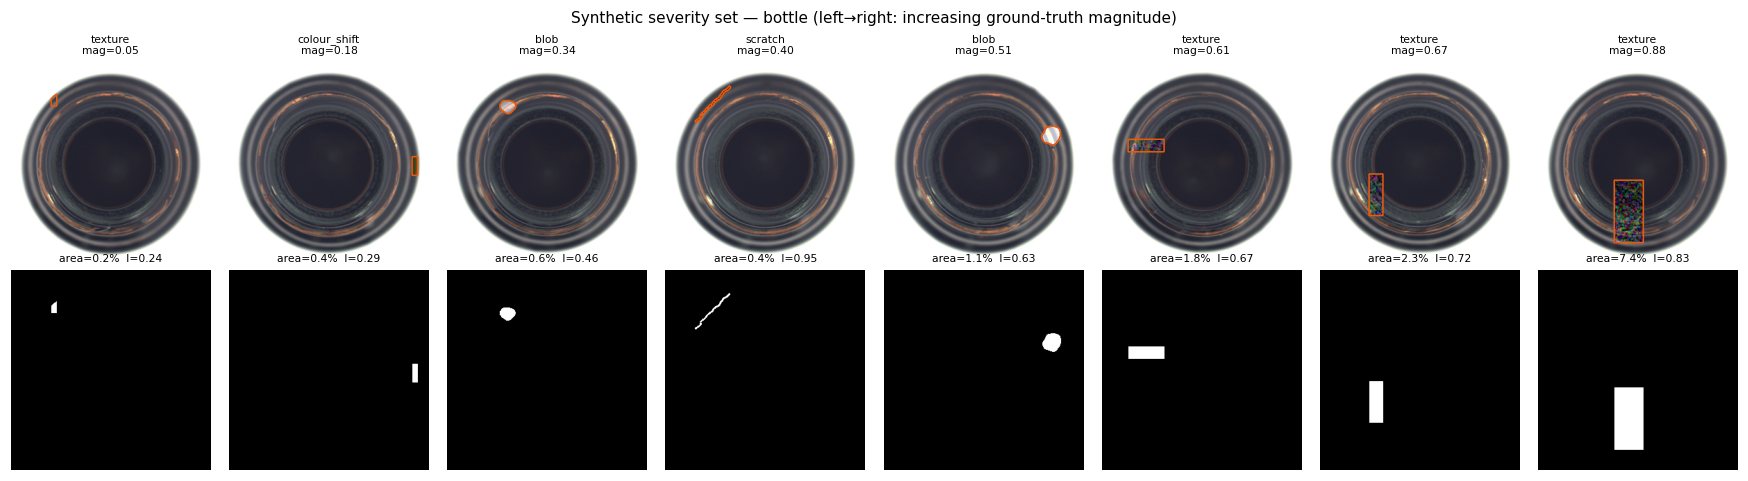

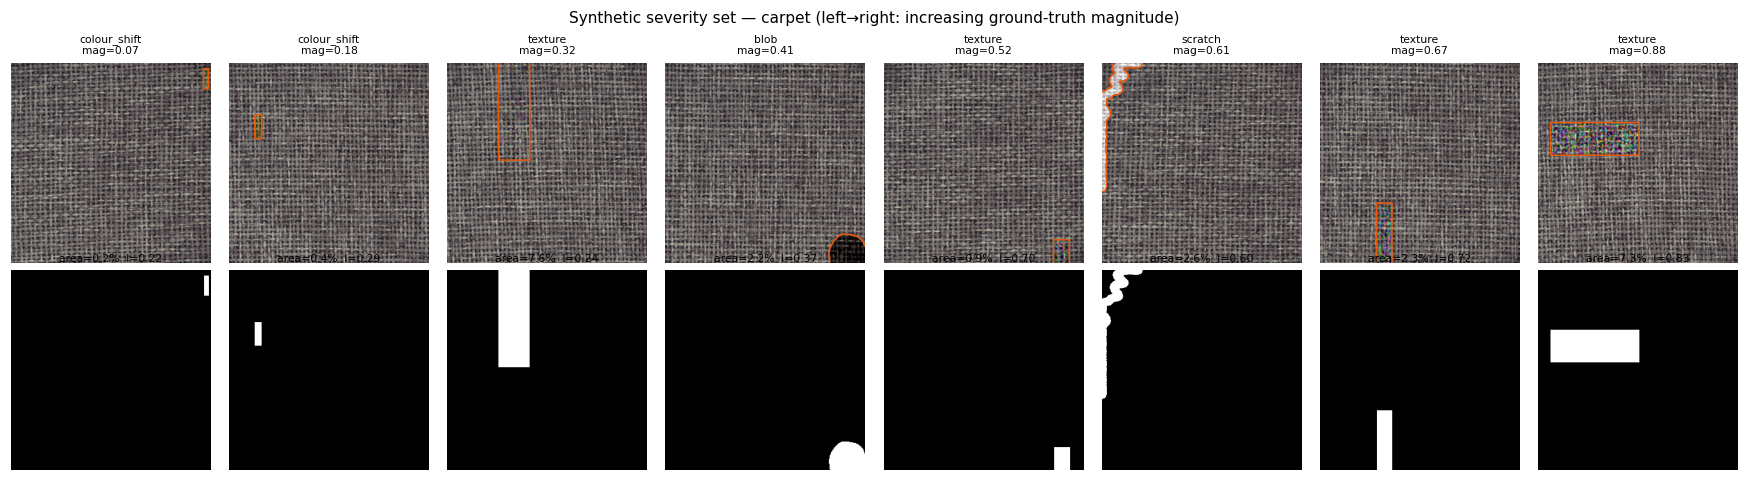

In [ ]:
# @title Gallery of generated defects, sorted by ground-truth magnitude
def show_synthetic_gallery(category: str, cfg: Config = CONFIG, n: int = 8):
    _, test_ds, _, _ = make_loaders(category, cfg)
    synth = SyntheticSeverityDataset(test_ds, cfg, seed=cfg.seeds[0])
    items = [synth[i] for i in range(min(len(synth), 4 * n))]
    items.sort(key=lambda d: d["true_magnitude"])
    picks = [items[int(round(t))] for t in np.linspace(0, len(items) - 1, n)]

    fig, axes = plt.subplots(2, n, figsize=(2.0 * n, 4.4))
    for j, it in enumerate(picks):
        img = denormalize(it["image"])
        axes[0][j].imshow(img)
        axes[0][j].contour(it["mask"][0].numpy(), levels=[0.5], colors=[PALETTE[3]], linewidths=1.0)
        axes[0][j].set_title(f"{it['defect']}\nmag={it['true_magnitude']:.2f}", fontsize=7)
        axes[1][j].imshow(it["mask"][0].numpy(), cmap="gray")
        axes[1][j].set_title(f"area={it['area_frac']*100:.1f}%  I={it['intensity']:.2f}", fontsize=7)
        for r in (0, 1):
            axes[r][j].axis("off")
    fig.suptitle(f"Synthetic severity set — {category} (left→right: increasing ground-truth magnitude)",
                 fontsize=10)
    fig.tight_layout()
    fig.savefig(Path(cfg.results_dir) / "figures" / f"synthetic_gallery_{category}.png", bbox_inches="tight")
    plt.show()


# One object category and one texture category is enough to see what the
# generator does; the remaining thirteen would look the same.
_gallery_cats = [c for c in CONFIG.categories[:1]]
for _c in ("carpet",):
    if _c in CONFIG.categories and _c not in _gallery_cats:
        _gallery_cats.append(_c)
for _cat in _gallery_cats:
    show_synthetic_gallery(_cat)

## 4. Backbone

All patch-based detectors share one frozen ImageNet backbone. Features from `layer2` and `layer3` are locally averaged over a 3×3 neighbourhood — this is what makes a "patch" describe a region rather than a point — resized to a common grid and concatenated. `layer2` carries texture and colour statistics, `layer3` carries structure; keeping both is what later lets us attribute a defect's feature distance to one or the other.

The choice of layers is a resolution/semantics trade-off. `layer1` fires on legitimate texture variation; `layer4` is 9×9 at this input size and localises nothing. At 288 px input, `layer2` gives a 36×36 grid — the resolution every anomaly map in this notebook inherits.

Extraction runs under fp16 autocast, which uses the T4's tensor cores and roughly halves the forward pass. Activations stay attached to the autograd graph because Grad-CAM needs to backpropagate through them; the Grad-CAM path runs in fp32.

In [ ]:
# @title Backbone feature extraction shared by every detector
class FeatureExtractor(nn.Module):
    """Frozen ImageNet backbone exposing intermediate feature maps via hooks.

    Activations are kept attached to the graph (not detached) because the
    Grad-CAM explanation needs to backpropagate through them.
    """

    def __init__(self, backbone: str = CONFIG.backbone, layers: Sequence[str] = CONFIG.layers):
        super().__init__()
        weights = "IMAGENET1K_V1"
        try:
            self.net = getattr(torchvision.models, backbone)(weights=weights)
        except Exception as exc:  # offline / weights unavailable
            print(f"[warn] pretrained weights unavailable ({type(exc).__name__}); using random init. "
                  "Results will be poor — re-run with network access.")
            self.net = getattr(torchvision.models, backbone)(weights=None)

        self.layers = list(layers)
        self._features: Dict[str, torch.Tensor] = {}
        for name in self.layers:
            getattr(self.net, name).register_forward_hook(self._make_hook(name))

        for p in self.net.parameters():
            p.requires_grad_(False)
        self.eval()
        self._channels: Optional[Dict[str, int]] = None

    def _make_hook(self, name: str):
        def hook(_module, _inp, out):
            self._features[name] = out
        return hook

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        self._features = {}
        self.net(x)
        return dict(self._features)

    @property
    def channels(self) -> Dict[str, int]:
        if self._channels is None:
            dummy = torch.zeros(1, 3, CONFIG.crop_size, CONFIG.crop_size,
                                device=next(self.net.parameters()).device)
            with torch.no_grad():
                f = self.forward(dummy)
            self._channels = {k: v.shape[1] for k, v in f.items()}
        return self._channels


def build_patch_embedding(
    feats: Dict[str, torch.Tensor],
    layers: Sequence[str],
    pool: int = CONFIG.patch_pool,
) -> torch.Tensor:
    """Concatenate multi-scale features into one vector per spatial patch.

    Each layer is locally averaged over a `pool`x`pool` neighbourhood (this is
    what makes a PatchCore patch describe a small region rather than a point),
    then bilinearly resized to the resolution of the first (finest) layer and
    concatenated along the channel axis.

    Returns: (B, C, H, W) with H,W the grid of the first requested layer.
    """
    ref = feats[layers[0]]
    _, _, h, w = ref.shape
    parts = []
    for name in layers:
        f = feats[name].float()
        f = F.avg_pool2d(f, kernel_size=pool, stride=1, padding=pool // 2)
        if f.shape[-2:] != (h, w):
            f = F.interpolate(f, size=(h, w), mode="bilinear", align_corners=False)
        parts.append(f)
    return torch.cat(parts, dim=1)


def embedding_to_patches(emb: torch.Tensor) -> torch.Tensor:
    """(B,C,H,W) -> (B*H*W, C) in row-major patch order."""
    b, c, h, w = emb.shape
    return emb.permute(0, 2, 3, 1).reshape(b * h * w, c)


@torch.no_grad()
def embed_images(extractor: FeatureExtractor, x: torch.Tensor) -> torch.Tensor:
    """Images -> (B,C,h,w) patch embedding, under fp16 autocast, returned as fp32."""
    with autocast():
        feats = extractor(x.to(DEVICE, non_blocking=True))
        emb = build_patch_embedding(feats, extractor.layers)
    return emb.float()


@torch.no_grad()
def extract_all(extractor: FeatureExtractor, loader: DataLoader, device=DEVICE):
    """Run the backbone over a loader; yields per-batch patch embeddings."""
    for batch in loader:
        yield batch, embed_images(extractor, batch["image"])


def upsample_map(patch_scores: torch.Tensor, size: int, sigma: float = 4.0) -> np.ndarray:
    """(H,W) patch-resolution scores -> smoothed (size,size) anomaly map.

    The Gaussian is not cosmetic: it suppresses isolated high-scoring patches
    that would otherwise become spurious connected components in the severity
    stage, and makes the field continuous enough to threshold stably.
    """
    m = patch_scores[None, None].float()
    m = F.interpolate(m, size=(size, size), mode="bilinear", align_corners=False)[0, 0]
    m = m.detach().cpu().numpy().astype(np.float32)
    return ndi.gaussian_filter(m, sigma=sigma)

## 5. Detectors

Three approaches behind one interface, chosen because they fail differently:

| | mechanism | strong when | weak when |
|---|---|---|---|
| **PatchCore** | nearest neighbour in a coreset memory bank | almost always; SOTA on MVTec | memory bank grows with training set |
| **PaDiM** | per-position Gaussian, Mahalanobis distance | objects are well aligned | pose varies (see `screw`) |
| **SSIM-AE** | reconstruction residual | large structural defects | it reconstructs the defect too |

PatchCore additionally records, for every bank vector, the training image and patch coordinate it came from. That bookkeeping cannot be retrofitted, and it is what makes the nearest-normal explanation possible.

**One shared convention.** The image-level score is the maximum of the *raw patch scores*, not the maximum of the smoothed map. The Gaussian blur exists to make region extraction stable; applied before the max it drags the peak down towards its neighbourhood, which costs image-level AUROC on exactly the small defects that are hardest to catch. Localisation uses the smoothed map, detection uses the raw peak.

In [ ]:
# @title Common detector interface + PatchCore
class AnomalyDetector:
    """All three detectors expose the same surface so they are interchangeable.

    fit(loader)                  -> learn the normal model
    calibrate(loader)            -> record the normal score distribution
    score_batch(images)          -> (image_scores [B], anomaly_maps [B,S,S])
    criticality_map(size)        -> optional positional structural-importance map
    release()                    -> drop heavy tensors once the run is scored
    """

    name = "base"

    def __init__(self, cfg: Config = CONFIG):
        self.cfg = cfg
        self.threshold: Optional[float] = None
        self.calib_scores: Optional[np.ndarray] = None
        self.calib_image_scores: Optional[np.ndarray] = None

    def fit(self, loader: DataLoader) -> "AnomalyDetector":
        raise NotImplementedError

    def _patch_scores(self, images: torch.Tensor) -> torch.Tensor:
        """(B,3,H,W) images -> (B,h,w) anomaly scores on the feature grid."""
        raise NotImplementedError

    @torch.no_grad()
    def score_batch(self, images: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
        ps = self._patch_scores(images)
        if self.cfg.tta_hflip:
            flipped = self._patch_scores(torch.flip(images, dims=[3]))
            ps = 0.5 * (ps + torch.flip(flipped, dims=[2]))
        b = ps.shape[0]
        # Localisation: smoothed, upsampled map. Detection: peak of the RAW patch
        # scores — smoothing first would pull the peak towards its neighbourhood
        # and systematically under-score small defects.
        maps = np.stack([upsample_map(ps[i], self.cfg.crop_size) for i in range(b)])
        img_scores = ps.reshape(b, -1).max(dim=1).values.detach().cpu().numpy()
        return img_scores, maps

    def score(self, image: torch.Tensor) -> Tuple[float, np.ndarray]:
        s, m = self.score_batch(image[None])
        return float(s[0]), m[0]

    def criticality_map(self, size: int) -> Optional[np.ndarray]:
        return None

    def calibrate(self, loader: DataLoader, max_pixels: int = 400_000) -> "AnomalyDetector":
        """Learn the pixel-score threshold from held-out *normal* images only.

        Using held-out normals (never the images in the memory bank) matters:
        scoring the bank images themselves gives near-zero distances and a
        threshold that is far too tight.
        """
        pix, img_scores = [], []
        rng = np.random.RandomState(self.cfg.seeds[0])
        n_batches = max(1, len(loader))
        for batch in loader:
            s, maps = self.score_batch(batch["image"])
            img_scores.append(s)
            flat = maps.reshape(-1)
            take = min(flat.size, max(1, max_pixels // n_batches))
            pix.append(flat[rng.choice(flat.size, take, replace=False)])
        self.calib_scores = np.concatenate(pix)
        self.calib_image_scores = np.concatenate(img_scores)
        self.threshold = float(np.percentile(self.calib_scores, self.cfg.severity_percentile))
        return self

    def normalize_score(self, s):
        """Map raw scores onto a comparable scale using the normal distribution."""
        if self.calib_scores is None:
            return s
        lo = float(np.percentile(self.calib_scores, 50))
        hi = float(np.percentile(self.calib_scores, 99.9))
        return np.clip((np.asarray(s) - lo) / max(hi - lo, 1e-8), 0, None)

    def release(self) -> None:
        """Free the large tensors. Called for every experiment we do not keep."""
        for attr in ("bank", "bank_coords", "inv_cov", "mean", "dim_idx", "model", "_faiss"):
            if hasattr(self, attr):
                setattr(self, attr, None)
        if hasattr(self, "train_thumbs"):
            self.train_thumbs = []
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()


# --------------------------------------------------------------------------- #
def greedy_coreset_indices(feats: torch.Tensor, n_select: int, proj_dim: int = None,
                           seed: int = 0) -> torch.Tensor:
    """Greedy k-center coreset selection (Sener & Savarese) on projected features.

    Picking the point furthest from everything already chosen preserves the
    coverage of the feature manifold far better than random subsampling, which
    is why PatchCore can throw away most of its patches and lose almost nothing.

    Cost is O(n_select * N * proj_dim); the caller caps n_select for that reason.
    """
    proj_dim = proj_dim or CONFIG.coreset_proj_dims
    g = torch.Generator(device="cpu").manual_seed(seed)
    n, c = feats.shape
    n_select = int(min(max(n_select, 1), n))

    # Johnson-Lindenstrauss projection keeps the distance geometry while making
    # each distance computation ~10x cheaper.
    if proj_dim < c:
        proj = torch.randn(c, proj_dim, generator=g).to(feats.device, feats.dtype) / math.sqrt(proj_dim)
        x = feats @ proj
    else:
        x = feats
    x = x.float()

    start = int(torch.randint(n, (1,), generator=g).item())
    selected = [start]
    min_d = torch.cdist(x, x[start:start + 1]).squeeze(1)
    for _ in range(n_select - 1):
        idx = int(torch.argmax(min_d).item())
        selected.append(idx)
        d = torch.cdist(x, x[idx:idx + 1]).squeeze(1)
        min_d = torch.minimum(min_d, d)
    return torch.tensor(selected, dtype=torch.long)


class PatchCore(AnomalyDetector):
    """Memory-bank nearest-neighbour anomaly detection.

    Beyond the standard algorithm we keep, for every bank vector, the training
    image and patch coordinate it came from. That bookkeeping is what makes the
    'closest normal pattern' explanation possible, and it cannot be added after
    the fact — so it is built in from the start.
    """

    name = "patchcore"

    def __init__(self, extractor: FeatureExtractor, cfg: Config = CONFIG):
        super().__init__(cfg)
        self.extractor = extractor
        self.bank: Optional[torch.Tensor] = None       # (M, C) float32 on device
        self.bank_coords: Optional[np.ndarray] = None  # (M, 3) = (img_idx, y, x)
        self.train_thumbs: List[np.ndarray] = []       # uint8 (H,W,3) for display
        self.grid: Tuple[int, int] = (0, 0)
        self.pos_var: Optional[np.ndarray] = None      # (h,w) positional variability
        self._faiss = None

    # ------------------------------------------------------------------ fit
    def fit(self, loader: DataLoader) -> "PatchCore":
        set_seed(self.cfg.seeds[0])
        feats_all, coords_all = [], []
        pos_sum = pos_sqsum = None
        n_imgs = 0

        t0 = time.time()
        for batch, emb in extract_all(self.extractor, loader):
            b, c, h, w = emb.shape
            self.grid = (h, w)
            # positional statistics (streaming) for the structural-relevance map
            e = emb.detach().float()
            if pos_sum is None:
                pos_sum = torch.zeros(c, h, w, device=e.device)
                pos_sqsum = torch.zeros(c, h, w, device=e.device)
            pos_sum += e.sum(0)
            pos_sqsum += (e ** 2).sum(0)

            # fp16 on CPU: the bank is built from hundreds of thousands of
            # 1536-dim vectors and fp32 would not fit in Colab RAM.
            feats_all.append(embedding_to_patches(e).cpu().half())

            yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
            for i in range(b):
                gi = n_imgs + i
                coords_all.append(np.stack([np.full(h * w, gi), yy.ravel(), xx.ravel()], 1))
                self.train_thumbs.append((denormalize(batch["image"][i]) * 255).astype(np.uint8))
            n_imgs += b

        feats = torch.cat(feats_all).to(DEVICE).float()
        del feats_all
        coords = np.concatenate(coords_all)

        mean = pos_sum / n_imgs
        var = (pos_sqsum / n_imgs - mean ** 2).clamp_min(0).mean(0)   # (h,w)
        self.pos_var = var.detach().cpu().numpy()
        del pos_sum, pos_sqsum, mean, var

        n_select = int(round(self.cfg.coreset_ratio * feats.shape[0]))
        n_select = max(16, min(n_select, self.cfg.coreset_max_bank))
        if n_select == self.cfg.coreset_max_bank:
            print(f"[PatchCore] coreset capped at {n_select} vectors "
                  f"({self.cfg.coreset_ratio:.0%} would have been "
                  f"{int(round(self.cfg.coreset_ratio * feats.shape[0]))})")
        sel = greedy_coreset_indices(feats, n_select, seed=self.cfg.seeds[0])
        self.bank = feats[sel.to(feats.device)].contiguous()
        self.bank_coords = coords[sel.numpy()]

        # faiss-cpu is only worth it without a GPU: moving queries to host memory
        # costs more than the torch matmul saves.
        if DEVICE.type != "cuda":
            try:
                import faiss
                index = faiss.IndexFlatL2(self.bank.shape[1])
                index.add(np.ascontiguousarray(self.bank.cpu().numpy()))
                self._faiss = index
            except Exception:
                self._faiss = None

        print(f"[PatchCore] {n_imgs} images -> {feats.shape[0]} patches -> "
              f"bank {self.bank.shape[0]} x {self.bank.shape[1]}  ({time.time()-t0:.1f}s)")
        del feats
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        return self

    # ---------------------------------------------------------------- search
    def _knn(self, patches: torch.Tensor, k: Optional[int] = None):
        """Return (distances [N,k], indices [N,k]) against the memory bank."""
        k = k or self.cfg.knn_k
        k = min(k, self.bank.shape[0])
        if self._faiss is not None:
            d2, idx = self._faiss.search(np.ascontiguousarray(patches.detach().cpu().numpy()), k)
            return torch.from_numpy(np.sqrt(np.maximum(d2, 0))), torch.from_numpy(idx)
        dists, idxs = [], []
        for chunk in torch.split(patches, 8192):
            d = torch.cdist(chunk, self.bank)
            dk, ik = torch.topk(d, k, dim=1, largest=False)
            dists.append(dk)
            idxs.append(ik)
        return torch.cat(dists), torch.cat(idxs)

    @torch.no_grad()
    def _patch_scores(self, images: torch.Tensor) -> torch.Tensor:
        emb = embed_images(self.extractor, images)
        b, c, h, w = emb.shape
        d, _ = self._knn(embedding_to_patches(emb))
        # mean of the top-k neighbours: smoother than 1-NN, less sensitive to a
        # single unlucky match in the bank.
        return d.mean(1).reshape(b, h, w)

    # -------------------------------------------------------- explainability
    @torch.no_grad()
    def nearest_normals(self, image: torch.Tensor, k: int = 3):
        """For every patch: distance + the training patches it is closest to."""
        emb = embed_images(self.extractor, image[None])
        _, c, h, w = emb.shape
        patches = embedding_to_patches(emb)
        d, idx = self._knn(patches, k=k)
        return {
            "patch_vectors": patches.cpu(),
            "dists": d.cpu().reshape(h, w, -1).numpy(),
            "indices": idx.cpu().reshape(h, w, -1).numpy(),
            "grid": (h, w),
        }

    def criticality_map(self, size: int) -> Optional[np.ndarray]:
        """Positions whose normal appearance is highly regular are structurally
        important: a deviation there is more likely to be a real defect than
        natural variation. We therefore invert the positional feature variance.
        """
        if self.pos_var is None:
            return None
        v = self.pos_var
        v = (v - v.min()) / (np.ptp(v) + 1e-8)
        crit = 1.0 - v
        crit = ndi.zoom(crit, (size / crit.shape[0], size / crit.shape[1]), order=1)
        return np.clip(crit, 0, 1)

In [ ]:
# @title PaDiM — per-position multivariate Gaussian of normal features
class PaDiM(AnomalyDetector):
    """Models each spatial position with its own Gaussian over reduced features.

    Where PatchCore asks "how far is this patch from any normal patch?", PaDiM
    asks "how unlikely is this patch *at this position*?". That positional prior
    makes it stronger on aligned objects and weaker on unaligned ones — which is
    why `screw`, photographed at arbitrary rotation, is where the two methods
    separate most clearly.

    Dimensionality reduction is not optional here: a covariance must be inverted
    per position, and at the backbone's native 1536 channels that matrix is both
    singular (fewer training images than dimensions) and far too large to hold
    once per grid cell.
    """

    name = "padim"

    def __init__(self, extractor: FeatureExtractor, cfg: Config = CONFIG):
        super().__init__(cfg)
        self.extractor = extractor
        self.dim_idx: Optional[torch.Tensor] = None
        self.mean: Optional[torch.Tensor] = None      # (HW, D)
        self.inv_cov: Optional[torch.Tensor] = None   # (HW, D, D)
        self.grid: Tuple[int, int] = (0, 0)

    def fit(self, loader: DataLoader) -> "PaDiM":
        set_seed(self.cfg.seeds[0])
        collected = []
        for _batch, emb in extract_all(self.extractor, loader):
            b, c, h, w = emb.shape
            self.grid = (h, w)
            if self.dim_idx is None:
                # Random channel selection: Defard et al. show it matches PCA
                # here at a fraction of the cost.
                d = min(self.cfg.padim_dims, c)
                g = torch.Generator().manual_seed(self.cfg.seeds[0])
                self.dim_idx = torch.randperm(c, generator=g)[:d].to(emb.device)
            e = emb.index_select(1, self.dim_idx).detach()          # (B,D,h,w)
            collected.append(e.permute(0, 2, 3, 1).reshape(b, h * w, -1).cpu())

        x = torch.cat(collected).to(DEVICE).float()                  # (N, HW, D)
        del collected
        n, hw, d = x.shape
        self.mean = x.mean(0)                                        # (HW, D)
        xc = x - self.mean[None]
        del x
        # Covariance per position, regularised so the inverse is well-conditioned
        # even when N < D (which it usually is).
        cov = torch.einsum("nkd,nke->kde", xc, xc) / max(n - 1, 1)
        del xc
        cov += self.cfg.padim_eps * torch.eye(d, device=cov.device)[None]
        self.inv_cov = torch.linalg.inv(cov)
        del cov
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"[PaDiM] N={n} positions={hw} dims={d}")
        return self

    @torch.no_grad()
    def _patch_scores(self, images: torch.Tensor) -> torch.Tensor:
        emb = embed_images(self.extractor, images)
        b, c, h, w = emb.shape
        e = emb.index_select(1, self.dim_idx).permute(0, 2, 3, 1).reshape(b, h * w, -1)
        delta = e - self.mean[None]                                   # (B,HW,D)
        # Mahalanobis distance, batched over positions.
        m = torch.einsum("bkd,kde,bke->bk", delta, self.inv_cov, delta).clamp_min(0).sqrt()
        return m.reshape(b, h, w)

In [ ]:
# @title SSIM Autoencoder — reconstruction-residual anomaly detection
#
# The third detector, and the one that fails differently from the other two:
# where PatchCore and PaDiM compare backbone features, this trains a small
# convolutional autoencoder to reconstruct normal images and scores the
# reconstruction residual. It catches large structural defects the feature
# detectors can wash out, and it misses low-contrast ones the AE happily
# reproduces. No ImageNet backbone is involved.


class _SSIM(nn.Module):
    """Differentiable SSIM with a Gaussian window; returns a per-pixel map."""

    def __init__(self, window: int = 11, sigma: float = 1.5, channels: int = 3):
        super().__init__()
        coords = torch.arange(window).float() - window // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        w2d = (g[:, None] * g[None, :])[None, None]
        self.register_buffer("w", w2d.expand(channels, 1, window, window).contiguous())
        self.channels = channels
        self.pad = window // 2

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        C1, C2 = 0.01 ** 2, 0.03 ** 2
        mu_x = F.conv2d(x, self.w, padding=self.pad, groups=self.channels)
        mu_y = F.conv2d(y, self.w, padding=self.pad, groups=self.channels)
        mx2, my2, mxy = mu_x ** 2, mu_y ** 2, mu_x * mu_y
        sx = F.conv2d(x * x, self.w, padding=self.pad, groups=self.channels) - mx2
        sy = F.conv2d(y * y, self.w, padding=self.pad, groups=self.channels) - my2
        sxy = F.conv2d(x * y, self.w, padding=self.pad, groups=self.channels) - mxy
        ssim = ((2 * mxy + C1) * (2 * sxy + C2)) / ((mx2 + my2 + C1) * (sx + sy + C2))
        return ssim.clamp(-1, 1).mean(1)                     # (B,H,W) in [-1,1]


class _ConvAE(nn.Module):
    """Symmetric conv autoencoder with a spatial (not flat) bottleneck, so it can
    reconstruct texture without memorising the exact layout of the training set.
    Four stride-2 stages: the input side must be divisible by 16."""

    def __init__(self, ch: int = 32, latent: int = 128):
        super().__init__()

        def enc(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 4, 2, 1), nn.BatchNorm2d(o),
                                 nn.LeakyReLU(0.2, inplace=True))

        def dec(i, o):
            return nn.Sequential(nn.ConvTranspose2d(i, o, 4, 2, 1), nn.BatchNorm2d(o),
                                 nn.ReLU(inplace=True))

        self.encoder = nn.Sequential(
            enc(3, ch), enc(ch, ch * 2), enc(ch * 2, ch * 4), enc(ch * 4, ch * 4),
            nn.Conv2d(ch * 4, latent, 1),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(latent, ch * 4, 1),
            dec(ch * 4, ch * 4), dec(ch * 4, ch * 2), dec(ch * 2, ch), dec(ch, ch),
            nn.Conv2d(ch, 3, 3, 1, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


class SSIMAutoencoder(AnomalyDetector):
    """Reconstruction-residual detector. Anomaly = local structural dissimilarity
    (1 - SSIM) plus per-pixel L2 between the image and its reconstruction."""

    name = "autoencoder"

    def __init__(self, cfg: Config = CONFIG):
        super().__init__(cfg)
        if cfg.crop_size % 16 != 0:
            raise ValueError(f"SSIM-AE needs crop_size divisible by 16, got {cfg.crop_size}")
        self.model = _ConvAE(ch=cfg.ae_base_ch).to(DEVICE)
        self.ssim = _SSIM().to(DEVICE)
        # score on a grid comparable to the backbone detectors so upsample_map's
        # Gaussian (tuned for a ~36x36 field) behaves the same way here.
        g = max(8, cfg.crop_size // 8)
        self.grid = (g, g)

    def fit(self, loader: DataLoader) -> "SSIMAutoencoder":
        set_seed(self.cfg.seeds[0])
        opt = torch.optim.Adam(self.model.parameters(), lr=self.cfg.ae_lr)
        self.model.train()
        t0 = time.time()
        last = 0.0
        for epoch in range(self.cfg.ae_epochs):
            tot, nb_ = 0.0, 0
            for batch in loader:
                x = batch["image"].to(DEVICE, non_blocking=True)
                if x.shape[0] < 2:            # BatchNorm needs >1 sample in train mode
                    continue
                rec = self.model(x)
                loss = F.mse_loss(rec, x) + 0.5 * (1.0 - self.ssim(rec, x).mean())
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()
                tot += float(loss.detach())
                nb_ += 1
            last = tot / max(nb_, 1)
        self.model.eval()
        print(f"[SSIM-AE] {self.cfg.ae_epochs} epochs, final loss {last:.4f} "
              f"({time.time() - t0:.1f}s)")
        return self

    @torch.no_grad()
    def _patch_scores(self, images: torch.Tensor) -> torch.Tensor:
        x = images.to(DEVICE, non_blocking=True)
        rec = self.model(x)
        dssim = (1.0 - self.ssim(rec, x)) * 0.5                # (B,H,W) in [0,1]
        l2 = ((rec - x) ** 2).mean(1)                          # (B,H,W)
        resid = dssim + l2
        return F.adaptive_avg_pool2d(resid[:, None], self.grid)[:, 0]


## 6. Severity-aware scoring

The contribution. An anomaly map is thresholded against a distribution learned from **held-out** normal images (never the ones in the memory bank — scoring those gives near-zero distances and an absurdly tight threshold), split into connected regions, and each region is described by five factors:

- **intensity** — how far above the normal-score distribution the region peaks;
- **extent** — area as a fraction of the *product*, not the frame, log-normalised;
- **structural relevance** — combines positions whose normal appearance is highly regular across training (a deviation there is more meaningful) with proximity to the object boundary, where geometry and sealing matter;
- **compactness** — $4\pi A/P^2$, separating a concentrated pit from a diffuse smudge;
- **contrast** — appearance gap between the region and the normal-looking ring around it.

Fusion is a transparent weighted sum by default. A learned alternative (Ridge / gradient boosting, fitted on the synthetic set) is reported alongside it so you can see how much the hand-set weights leave on the table.

In [ ]:
# @title Severity-aware anomaly scoring — the core contribution
#
# A conventional anomaly score answers "is this part defective?". A maintenance
# team needs "which of today's 400 flagged parts do I look at first?". Those are
# different questions: a faint 0.9-score scratch across a sealing surface can
# matter far more than a bright 0.95-score speck on a cosmetic face. The scorer
# below decomposes each flagged region into interpretable factors and fuses them
# into a severity that is meant to track industrial impact, not raw distance.

from skimage.measure import regionprops, label as sk_label

SEVERITY_LABELS = ("Negligible", "Minor", "Major", "Critical")
FACTORS = list(CONFIG.severity_weights.keys())


@dataclass
class DefectRegion:
    region_id: int
    mask: np.ndarray
    area_px: int
    area_frac: float           # of the object, not the frame
    centroid: Tuple[float, float]
    bbox: Tuple[int, int, int, int]
    factors: Dict[str, float]
    severity: float
    severity_class: str

    def summary_row(self) -> Dict:
        return {"region": self.region_id, "area_px": self.area_px, "area_frac": self.area_frac,
                "severity": self.severity, "class": self.severity_class, **self.factors}


@dataclass
class SeverityReport:
    regions: List[DefectRegion]
    anomaly_map: np.ndarray
    binary_mask: np.ndarray
    object_mask: np.ndarray
    overall: float             # max region severity — drives triage
    weighted: float            # area-weighted mean — drives batch quality stats
    severity_class: str

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame([r.summary_row() for r in self.regions])


def _saturate(x: float, scale: float = 1.0) -> float:
    """Bounded, monotone, no upper clipping: maps [0,inf) -> [0,1)."""
    x = max(float(x), 0.0)
    return x / (x + scale)


def _log_normalise(v: float, lo: float, hi: float) -> float:
    v = max(v, 1e-6)
    return float(np.clip((math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo)), 0, 1))


def fuse_with(factors: Dict[str, float], weights: Dict[str, float]) -> float:
    """Weighted-sum fusion as a free function.

    Deliberately not a method: the ablation and the learned-fusion comparison
    both need it after the detector that produced the factors has been released
    from memory, and a pure function of (factors, weights) has no such coupling.
    """
    total = sum(weights.values()) or 1.0
    return float(np.clip(sum(weights.get(k, 0.0) * factors.get(k, 0.0) for k in weights) / total, 0, 1))


def classify_severity(severity: float, cfg: Config = CONFIG) -> str:
    return SEVERITY_LABELS[int(np.digitize(severity, cfg.severity_bins))]


class SeverityScorer:
    """Turns an anomaly map into ranked, explained defect regions."""

    def __init__(self, detector: AnomalyDetector, cfg: Config = CONFIG):
        self.detector = detector
        self.cfg = cfg
        self.weights = dict(cfg.severity_weights)
        self.learned_model = None          # set by fit_learned()
        self.factor_names = list(cfg.severity_weights.keys())
        self._crit_cache: Dict[int, Optional[np.ndarray]] = {}

    # ------------------------------------------------------------- factors
    def _structural_map(self, object_mask: np.ndarray, size: int,
                        roi: Optional[np.ndarray] = None) -> np.ndarray:
        """Positional structural importance in [0,1].

        Two ingredients, both unsupervised:
          * detector criticality — positions whose *normal* appearance varies
            little across the training set are highly regular, so a deviation
            there is more meaningful (PatchCore supplies this; others fall back
            to uniform);
          * boundary proximity — edges, rims and seams are where geometry and
            sealing matter, so proximity to the object boundary raises weight.
        """
        if size not in self._crit_cache:
            self._crit_cache[size] = self.detector.criticality_map(size)
        crit = self._crit_cache[size]
        if crit is None:
            crit = np.full((size, size), 0.5, np.float32)

        dist = ndi.distance_transform_edt(object_mask)
        edge_prox = 1.0 - dist / (dist.max() + 1e-8)
        s = 0.5 * crit + 0.5 * edge_prox
        if roi is not None:
            s = np.clip(s * (0.5 + roi.astype(np.float32)), 0, 1)
        return np.clip(s, 0, 1)

    def _region_contrast(self, img: np.ndarray, region: np.ndarray, ring_px: int = 6) -> float:
        """Appearance gap between the region and the normal-looking ring around it."""
        dil = morphology.dilation(region, morphology.disk(ring_px))
        ring = dil & ~region
        if ring.sum() < 8 or region.sum() < 1:
            return 0.0
        gap = np.abs(img[region].mean(0) - img[ring].mean(0)).mean()
        spread = img.std() + 1e-6
        return _saturate(gap / spread, scale=0.5)

    # -------------------------------------------------------------- assess
    def assess(
        self,
        image: np.ndarray,
        anomaly_map: np.ndarray,
        object_mask: Optional[np.ndarray] = None,
        roi: Optional[np.ndarray] = None,
        threshold: Optional[float] = None,
        path: Optional[str] = None,
    ) -> SeverityReport:
        """image: (H,W,3) in [0,1]; anomaly_map: (H,W) raw detector scores."""
        size = anomaly_map.shape[0]
        obj = object_mask if object_mask is not None else object_mask_for(path, image)
        obj_area = max(int(obj.sum()), 1)
        thr = threshold if threshold is not None else self.detector.threshold
        if thr is None:
            thr = float(np.percentile(anomaly_map, self.cfg.severity_percentile))
        base = float(np.median(self.detector.calib_scores)) if self.detector.calib_scores is not None \
            else float(np.median(anomaly_map))
        span = max(thr - base, 1e-8)

        binary = (anomaly_map > thr) & obj
        binary = remove_small_regions(binary, self.cfg.min_region_px)
        if not binary.any():
            # Nothing clears the threshold. There is no region to characterise,
            # so severity is defined only by how close the hottest spot came —
            # NOT by fabricating a region and scoring its shape and location,
            # which was letting clean parts outrank real defects in the queue.
            peak = float(np.max(np.where(obj, anomaly_map, -np.inf)))
            approach = float(np.clip((peak - base) / span, 0.0, 1.0))
            sev = 0.15 * approach ** 2
            return SeverityReport([], anomaly_map, np.zeros_like(obj), obj,
                                  sev, sev, classify_severity(sev, self.cfg))

        struct_map = self._structural_map(obj, size, roi)
        labels = sk_label(binary)
        regions: List[DefectRegion] = []

        for i, prop in enumerate(regionprops(labels), start=1):
            m = labels == prop.label
            vals = anomaly_map[m]
            p95 = float(np.percentile(vals, 95))

            # How far the region peaks *past* the detection threshold, in units
            # of the normal band (median -> 99.5th percentile). The old form
            # subtracted 1.0 and used scale=1.0, which needed a full extra band
            # above threshold just to register above zero — so this factor read
            # ~0 for almost every real MVTec defect despite carrying 30% weight.
            f_intensity = _saturate(max(p95 - thr, 0.0) / span, scale=0.5)
            f_extent = _log_normalise(m.sum() / obj_area, *self.cfg.synth_area_range)
            f_structural = float(struct_map[m].mean())
            perim = max(prop.perimeter, 1e-6)
            f_compact = float(np.clip(4 * math.pi * prop.area / (perim ** 2), 0, 1))
            f_contrast = self._region_contrast(image, m)

            factors = {
                "intensity": f_intensity,
                "extent": f_extent,
                "structural": f_structural,
                "compactness": f_compact,
                "contrast": f_contrast,
            }
            sev = self.fuse(factors)
            regions.append(DefectRegion(
                region_id=i, mask=m, area_px=int(m.sum()), area_frac=float(m.sum() / obj_area),
                centroid=tuple(prop.centroid), bbox=tuple(prop.bbox),
                factors=factors, severity=sev, severity_class=classify_severity(sev, self.cfg),
            ))

        regions.sort(key=lambda r: -r.severity)
        overall = max((r.severity for r in regions), default=0.0)
        total_area = sum(r.area_px for r in regions) or 1
        weighted = sum(r.severity * r.area_px for r in regions) / total_area
        return SeverityReport(regions, anomaly_map, binary, obj, overall, weighted,
                              classify_severity(overall, self.cfg))

    # --------------------------------------------------------------- fusion
    def fuse(self, factors: Dict[str, float]) -> float:
        """Weighted sum by default; the learned regressor when one is fitted."""
        if self.learned_model is not None:
            x = np.array([[factors[k] for k in self.factor_names]])
            return float(np.clip(self.learned_model.predict(x)[0], 0, 1))
        return fuse_with(factors, self.weights)

    def fuse_with(self, factors: Dict[str, float], weights: Dict[str, float]) -> float:
        return fuse_with(factors, weights)

    def classify(self, severity: float) -> str:
        return classify_severity(severity, self.cfg)

    def use_manual_weights(self):
        self.learned_model = None
        return self


def fit_learned_fusion(factor_rows: List[Dict[str, float]], targets: Sequence[float],
                       model: str = "ridge", factor_names: Sequence[str] = None,
                       verbose: bool = False):
    """Fit factors -> ground-truth magnitude on the synthetic set.

    The hand-set weights are transparent; the learned version shows how much
    (if anything) is left on the table by not tuning them. Both are reported.
    Standalone so it can run after the detectors have been freed.
    """
    from sklearn.linear_model import RidgeCV
    from sklearn.ensemble import GradientBoostingRegressor

    names = list(factor_names or FACTORS)
    X = np.array([[r[k] for k in names] for r in factor_rows])
    y = np.asarray(targets, float)
    est = RidgeCV(alphas=np.logspace(-3, 2, 12)) if model == "ridge" else \
        GradientBoostingRegressor(random_state=CONFIG.seeds[0], n_estimators=150, max_depth=3)
    est.fit(X, y)
    if verbose and hasattr(est, "coef_"):
        print("[severity] learned weights: " +
              ", ".join(f"{k}={c:+.3f}" for k, c in zip(names, est.coef_)))
    return est

## 7. Explainability

Three levels, answering different questions:

- **Where** — anomaly map, region contours annotated with severity.
- **Why (model)** — Grad-CAM. PatchCore's k-NN lookup is not differentiable, but the distance to an *already-selected* neighbour is: we retrieve under `no_grad`, detach, and backpropagate the resulting distance.
- **Why (reference)** — the closest normal patch from the memory bank, its source training image and coordinate, the feature dimensions driving the gap, and how the distance splits across backbone layers. A `layer2`-dominated gap means a texture/colour deviation; `layer3`-dominated means a structural one.

Textual summaries use deterministic templates rather than a language model, so every clause is traceable to a number in the factor vector. An optional LLM-polish step is available behind an API-key check.

In [ ]:
# @title Explainability — heatmaps, Grad-CAM, and nearest-normal comparison
#
# Three levels of explanation, each answering a different question:
#   WHERE  — the anomaly map and region contours
#   WHY (model) — Grad-CAM: which backbone evidence drove the score
#   WHY (reference) — the closest normal patch in the memory bank, and which
#                     feature groups separate the two. This last one is the part
#                     an operator can actually argue with: "here is what this
#                     spot is supposed to look like, and here is how it differs."


def grad_cam(detector: AnomalyDetector, image: torch.Tensor, layer: Optional[str] = None,
             top_p: float = 0.05) -> np.ndarray:
    """Gradient-weighted class activation map w.r.t. the anomaly score.

    PatchCore's k-NN lookup is not differentiable, but the *distance to an
    already-selected* neighbour is. We therefore find the nearest bank vectors
    under no_grad, detach them, and backpropagate the resulting distance — the
    standard trick for making retrieval-based scores CAM-compatible.

    Runs in fp32: autocast is for the inference-only extraction path, and mixed
    precision through a backward pass would need loss scaling for no benefit at
    this scale.

    Supports the feature-embedding detectors only (PatchCore, PaDiM); anything
    else is rejected rather than silently routed through the PaDiM branch.
    """
    if not isinstance(detector, (PatchCore, PaDiM)):
        raise TypeError(
            f"grad_cam supports PatchCore and PaDiM, got {type(detector).__name__}"
        )

    ext = detector.extractor
    layer = layer or ext.layers[-1]
    x = image[None].to(DEVICE).clone().requires_grad_(True)
    feats = ext(x)
    act = feats[layer]
    emb = build_patch_embedding(feats, ext.layers)
    patches = embedding_to_patches(emb)

    if isinstance(detector, PatchCore):
        with torch.no_grad():
            _, idx = detector._knn(patches, k=1)
        ref = detector.bank[idx[:, 0].to(detector.bank.device)].detach()
        dist = ((patches - ref) ** 2).sum(1).clamp_min(1e-12).sqrt()
    else:  # PaDiM
        e = emb.index_select(1, detector.dim_idx).permute(0, 2, 3, 1).reshape(1, -1, detector.mean.shape[1])
        delta = e - detector.mean[None]
        dist = torch.einsum("bkd,kde,bke->bk", delta, detector.inv_cov, delta).clamp_min(1e-12).sqrt()[0]

    k = max(1, int(top_p * dist.numel()))
    score = dist.topk(k).values.mean()
    grads = torch.autograd.grad(score, act)[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * act).sum(1))[0]
    cam = cam.detach().cpu().numpy()
    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    return ndi.zoom(cam, (image.shape[1] / cam.shape[0], image.shape[2] / cam.shape[1]), order=1)


def _patch_crop(img: np.ndarray, y: int, x: int, grid: Tuple[int, int], context: int = 1) -> np.ndarray:
    """Crop the image region corresponding to patch (y,x) of the feature grid."""
    h, w = img.shape[:2]
    cy, cx = h / grid[0], w / grid[1]
    y0 = int(max(0, (y - context) * cy)); y1 = int(min(h, (y + 1 + context) * cy))
    x0 = int(max(0, (x - context) * cx)); x1 = int(min(w, (x + 1 + context) * cx))
    return img[y0:y1, x0:x1]


def nearest_normal_analysis(detector: AnomalyDetector, image: torch.Tensor, region: DefectRegion,
                            k: int = 3) -> Optional[Dict]:
    """Retrieve the closest normal patches for the peak patch of a defect region."""
    if not isinstance(detector, PatchCore) or detector.bank is None:
        return None

    nn_info = detector.nearest_normals(image, k=k)
    gh, gw = nn_info["grid"]
    # Map the region mask onto the feature grid and take its most anomalous cell.
    small = ndi.zoom(region.mask.astype(np.float32), (gh / region.mask.shape[0], gw / region.mask.shape[1]),
                     order=0) > 0.5
    if not small.any():
        cy, cx = region.centroid
        small = np.zeros((gh, gw), bool)
        small[int(cy * gh / region.mask.shape[0]), int(cx * gw / region.mask.shape[1])] = True

    d0 = nn_info["dists"][..., 0]
    masked = np.where(small, d0, -np.inf)
    py, px = np.unravel_index(np.argmax(masked), masked.shape)

    q_vec = nn_info["patch_vectors"][py * gw + px].numpy()
    neigh = []
    query_img = denormalize(image)
    for j in range(k):
        bank_i = int(nn_info["indices"][py, px, j])
        img_idx, ny, nx = detector.bank_coords[bank_i]
        n_vec = detector.bank[bank_i].detach().cpu().numpy()
        neigh.append({
            "bank_index": bank_i,
            "train_image": int(img_idx),
            "coord": (int(ny), int(nx)),
            "distance": float(nn_info["dists"][py, px, j]),
            "crop": _patch_crop(detector.train_thumbs[int(img_idx)].astype(np.float32) / 255,
                                int(ny), int(nx), (gh, gw)),
            "vector": n_vec,
        })

    diff = np.abs(q_vec - neigh[0]["vector"])
    # Attribute the distance to the backbone layers the embedding was built from.
    ch = detector.extractor.channels
    layer_sizes = [ch[l] for l in detector.extractor.layers]
    bounds, acc = [], 0
    for s in layer_sizes:
        bounds.append((acc, acc + s)); acc += s
    layer_contrib = {l: float((diff[a:b] ** 2).sum()) for l, (a, b) in zip(detector.extractor.layers, bounds)}
    tot = sum(layer_contrib.values()) or 1.0
    layer_contrib = {l: v / tot for l, v in layer_contrib.items()}

    return {
        "patch": (int(py), int(px)),
        "grid": (gh, gw),
        "query_crop": _patch_crop(query_img, int(py), int(px), (gh, gw)),
        "neighbours": neigh,
        "diff": diff,
        "layer_contribution": layer_contrib,
        "top_dims": np.argsort(-diff)[:16],
    }


def describe_region(region: DefectRegion, nn_analysis: Optional[Dict], category: str) -> str:
    """Rule-based natural-language summary of one defect.

    Deterministic templates rather than a language model: the sentence has to be
    auditable, and every clause below is traceable to a number in `factors`.
    """
    f = region.factors
    shape = "compact" if f["compactness"] > 0.6 else ("elongated" if f["compactness"] < 0.3 else "irregular")
    size = ("a large" if f["extent"] > 0.66 else "a moderate" if f["extent"] > 0.33 else "a small")
    loc = ("in a structurally critical zone (regular geometry / near the object boundary)"
           if f["structural"] > 0.6 else
           "in a structurally tolerant zone" if f["structural"] < 0.35 else
           "in a moderately critical zone")
    contrast = ("high-contrast" if f["contrast"] > 0.6 else
                "low-contrast" if f["contrast"] < 0.3 else "moderate-contrast")

    txt = (f"{region.severity_class} defect (severity {region.severity:.2f}) on the {category}: "
           f"{size} {shape}, {contrast} region covering {region.area_frac*100:.2f}% of the product, {loc}. "
           f"Anomaly intensity factor {f['intensity']:.2f}, extent {f['extent']:.2f}, "
           f"structural relevance {f['structural']:.2f}.")

    if nn_analysis:
        lc = nn_analysis["layer_contribution"]
        dom = max(lc, key=lc.get)
        kind = ("low-level texture/colour statistics" if dom.endswith("2") else
                "higher-level structural/shape features")
        d0 = nn_analysis["neighbours"][0]
        txt += (f" The closest normal pattern in the memory bank (training image {d0['train_image']}, "
                f"patch {d0['coord']}, distance {d0['distance']:.2f}) differs mainly in {kind} "
                f"({dom} accounts for {lc[dom]*100:.0f}% of the feature distance).")
    return txt


def polish_with_llm(text: str, model: str = "gpt-4o-mini") -> str:
    """Optionally rephrase the deterministic summary in fluent prose.

    No-op unless OPENAI_API_KEY is set in the environment — the template text
    is the source of truth and the pipeline never depends on a network call.
    When a key is present this only smooths phrasing; the system prompt forbids
    adding or changing any number or severity class, so every figure in the
    output still traces back to the factor vector.
    """
    key = os.environ.get("OPENAI_API_KEY")
    if not key:
        return text
    try:
        from openai import OpenAI
        client = OpenAI(api_key=key)
        resp = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": (
                    "Rewrite this industrial-inspection note in one or two clear "
                    "sentences for a maintenance engineer. Keep every number, "
                    "percentage and severity class exactly as given. Do not add, "
                    "drop or reinterpret any finding.")},
                {"role": "user", "content": text},
            ],
            temperature=0.2, max_tokens=200,
        )
        return resp.choices[0].message.content.strip()
    except Exception as exc:
        print(f"[polish_with_llm] using the template ({type(exc).__name__}: {exc})")
        return text


def explain_image(detector: AnomalyDetector, scorer: SeverityScorer, image: torch.Tensor,
                  category: str = "", gt_mask: Optional[np.ndarray] = None,
                  show: bool = True, save_path: Optional[Path] = None) -> Dict:
    """Full explanation panel for a single image."""
    img = denormalize(image)
    img_score, amap = detector.score(image)
    report = scorer.assess(img, amap)
    top = report.regions[0] if report.regions else None
    try:
        cam = grad_cam(detector, image)
    except TypeError:                       # detector without a differentiable score (SSIM-AE)
        cam = np.zeros((image.shape[1], image.shape[2]), np.float32)
    nn_an = nearest_normal_analysis(detector, image, top) if top is not None else None
    text = describe_region(top, nn_an, category or "product") if top is not None else "No defect region found."

    if show:
        fig = plt.figure(figsize=(13, 6.4))
        gs = fig.add_gridspec(2, 4, height_ratios=[1, 0.85], hspace=0.28, wspace=0.12)

        ax = fig.add_subplot(gs[0, 0]); ax.imshow(img); ax.set_title("input", fontsize=9)
        if gt_mask is not None and gt_mask.any():
            ax.contour(gt_mask, levels=[0.5], colors=["#FFFFFF"], linewidths=1.0, linestyles="--")
        ax.axis("off")

        ax = fig.add_subplot(gs[0, 1]); ax.imshow(img)
        im = ax.imshow(amap, cmap="jet", alpha=0.5)
        ax.set_title(f"anomaly map (score {img_score:.2f})", fontsize=9); ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        ax = fig.add_subplot(gs[0, 2]); ax.imshow(img)
        for r in report.regions[:5]:
            ax.contour(r.mask, levels=[0.5], colors=[PALETTE[3]], linewidths=1.3)
            ax.text(r.centroid[1], r.centroid[0], f"{r.severity:.2f}", color="white", fontsize=8,
                    ha="center", va="center", bbox=dict(fc=PALETTE[3], ec="none", alpha=0.85, pad=1.2))
        ax.set_title(f"regions — overall {report.overall:.2f} ({report.severity_class})", fontsize=9)
        ax.axis("off")

        ax = fig.add_subplot(gs[0, 3]); ax.imshow(img); ax.imshow(cam, cmap="inferno", alpha=0.55)
        ax.set_title("Grad-CAM", fontsize=9); ax.axis("off")

        if nn_an is not None:
            ax = fig.add_subplot(gs[1, 0]); ax.imshow(np.clip(nn_an["query_crop"], 0, 1))
            ax.set_title("anomalous patch", fontsize=9); ax.axis("off")

            ax = fig.add_subplot(gs[1, 1]); ax.imshow(np.clip(nn_an["neighbours"][0]["crop"], 0, 1))
            n0 = nn_an["neighbours"][0]
            ax.set_title(f"closest normal (train#{n0['train_image']}, d={n0['distance']:.1f})", fontsize=9)
            ax.axis("off")

            ax = fig.add_subplot(gs[1, 2])
            dims = nn_an["top_dims"]
            ax.bar(range(len(dims)), nn_an["diff"][dims], color=PALETTE[0])
            ax.set_xticks(range(len(dims))); ax.set_xticklabels(dims, rotation=90, fontsize=5)
            ax.set_title("top feature dimensions driving the gap", fontsize=9)
            ax.set_ylabel("|Δ feature|", fontsize=8)

            ax = fig.add_subplot(gs[1, 3])
            lc = nn_an["layer_contribution"]
            ax.bar(list(lc.keys()), list(lc.values()), color=PALETTE[2])
            ax.set_ylim(0, 1); ax.set_title("distance attribution by layer", fontsize=9)

        fig.suptitle(text, fontsize=8.5, y=0.995, wrap=True)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        if save_path:
            fig.savefig(save_path, bbox_inches="tight")
        plt.show()

    return {"image_score": img_score, "report": report, "cam": cam,
            "nearest_normal": nn_an, "text": text}


## 8. Metrics

Two families, measuring different claims. **Detection** metrics (image AUROC, pixel AUROC, PRO) say whether a part is defective and where — computed on MVTec, where ground-truth masks exist. **Ranking** metrics (Spearman, Kendall, nDCG, rank MAE) say whether the worst defects come first — computed on the synthetic set, because MVTec carries no severity ground truth.

PRO deserves a note: it weights every ground-truth region equally, so a method cannot score well by nailing one large defect while missing all the small ones. That is precisely the failure mode pixel AUROC hides, since pixel AUROC is dominated by whichever defect has the most pixels.

In [ ]:
# @title Metrics — detection quality and severity-ranking quality
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr, kendalltau, rankdata

# numpy >=2.0 renamed trapz -> trapezoid; Colab may ship either.
_trapz = getattr(np, "trapezoid", None) or np.trapz


def image_auroc(scores: np.ndarray, labels: np.ndarray) -> float:
    if len(np.unique(labels)) < 2:
        return float("nan")
    return float(roc_auc_score(labels, scores))


def image_ap(scores: np.ndarray, labels: np.ndarray) -> float:
    if len(np.unique(labels)) < 2:
        return float("nan")
    return float(average_precision_score(labels, scores))


def pixel_auroc(maps: np.ndarray, masks: np.ndarray, max_pixels: int = 2_000_000) -> float:
    y = masks.reshape(-1).astype(np.uint8)
    s = maps.reshape(-1)
    if len(np.unique(y)) < 2:
        return float("nan")
    if y.size > max_pixels:  # subsample, keeping every positive pixel
        rng = np.random.RandomState(0)
        pos = np.where(y == 1)[0]
        neg = np.where(y == 0)[0]
        neg = rng.choice(neg, size=min(len(neg), max(1, max_pixels - len(pos))), replace=False)
        keep = np.concatenate([pos, neg])
        y, s = y[keep], s[keep]
    return float(roc_auc_score(y, s))


def pro_score(maps: np.ndarray, masks: np.ndarray, n_thresholds: int = 30,
              fpr_limit: float = 0.3) -> float:
    """Per-Region Overlap, integrated up to `fpr_limit` and normalised.

    PRO weights every ground-truth region equally, so a method cannot score well
    by nailing one huge defect while missing all the small ones — which is
    exactly the failure mode pixel-AUROC hides.
    """
    if masks.sum() == 0 or len(maps) == 0:
        return float("nan")
    thresholds = np.linspace(maps.min(), maps.max(), n_thresholds)
    pros, fprs = [], []
    labelled = [sk_label(m > 0.5) for m in masks]
    neg_total = float((masks < 0.5).sum())

    for t in thresholds:
        pred = maps > t
        overlaps, fp = [], 0.0
        for i, lab in enumerate(labelled):
            for r in range(1, lab.max() + 1):
                region = lab == r
                overlaps.append((pred[i] & region).sum() / max(region.sum(), 1))
            fp += float((pred[i] & (masks[i] < 0.5)).sum())
        if overlaps:
            pros.append(np.mean(overlaps))
            fprs.append(fp / max(neg_total, 1))

    pros, fprs = np.array(pros), np.array(fprs)
    order = np.argsort(fprs)
    pros, fprs = pros[order], fprs[order]
    keep = fprs <= fpr_limit
    if keep.sum() < 2:
        return float("nan")
    return float(_trapz(pros[keep], fprs[keep]) / fpr_limit)


# ------------------------------------------------------------------ ranking
def ndcg_at_k(pred: np.ndarray, true_relevance: np.ndarray, k: int) -> float:
    """Normalised discounted cumulative gain of the ranking induced by `pred`."""
    k = min(k, len(pred))
    order = np.argsort(-np.asarray(pred))[:k]
    gains = np.asarray(true_relevance)[order]
    disc = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = float((gains * disc).sum())
    ideal = np.sort(np.asarray(true_relevance))[::-1][:k]
    idcg = float((ideal * disc).sum())
    return dcg / idcg if idcg > 0 else float("nan")


def precision_at_k(pred: np.ndarray, true_relevance: np.ndarray, k: int, top_frac: float = 0.2) -> float:
    """Fraction of the predicted top-k that belongs to the truly worst `top_frac`."""
    n = len(pred)
    k = min(k, n)
    n_true = max(1, int(round(top_frac * n)))
    truly_worst = set(np.argsort(-np.asarray(true_relevance))[:n_true].tolist())
    predicted = np.argsort(-np.asarray(pred))[:k]
    return float(np.mean([i in truly_worst for i in predicted]))


def mean_abs_rank_error(pred: np.ndarray, true: np.ndarray) -> float:
    """Average rank displacement, normalised by n so it is comparable across sets."""
    n = len(pred)
    return float(np.abs(rankdata(-np.asarray(pred)) - rankdata(-np.asarray(true))).mean() / n)


def ranking_metrics(pred: Sequence[float], true: Sequence[float], prefix: str = "") -> Dict[str, float]:
    pred, true = np.asarray(pred, float), np.asarray(true, float)
    ok = np.isfinite(pred) & np.isfinite(true)
    pred, true = pred[ok], true[ok]
    if len(pred) < 3 or np.std(pred) == 0:
        return {f"{prefix}spearman": float("nan"), f"{prefix}kendall": float("nan"),
                f"{prefix}ndcg@10%": float("nan"), f"{prefix}ndcg@20%": float("nan"),
                f"{prefix}prec@10%": float("nan"), f"{prefix}rank_mae": float("nan")}
    k10 = max(1, int(0.1 * len(pred)))
    k20 = max(1, int(0.2 * len(pred)))
    return {
        f"{prefix}spearman": float(spearmanr(pred, true).correlation),
        f"{prefix}kendall": float(kendalltau(pred, true).correlation),
        f"{prefix}ndcg@10%": ndcg_at_k(pred, true, k10),
        f"{prefix}ndcg@20%": ndcg_at_k(pred, true, k20),
        f"{prefix}prec@10%": precision_at_k(pred, true, k10),
        f"{prefix}rank_mae": mean_abs_rank_error(pred, true),
    }

## 9. Experiment runner

Fit → calibrate on held-out normals → evaluate on MVTec → evaluate on the synthetic severity set, for every (category, detector) pair. With 15 categories and 3 detectors that is 45 experiments.

**Memory is the binding constraint, not compute.** Each experiment produces a memory bank (or a stack of per-position inverse covariances) on the GPU and a few hundred megabytes of anomaly maps in host RAM. Keeping all 45 alive would exhaust both several categories in. The runner therefore extracts the metrics and the small per-image dataframes, then releases everything heavy — except for one designated experiment (`CONFIG.qualitative_category` with PatchCore) that the qualitative, sensitivity and robustness sections need to keep alive.

In [ ]:
# @title Experiment runner — fits every detector on every category
from torch.utils.data import Subset

DETECTORS = ("patchcore", "padim", "autoencoder")
# Keys kept in every result dict; everything else is dropped after scoring.
_LIGHT_KEYS = ("scores", "labels", "defects", "paths", "true_magnitude",
               "impact_magnitude", "area_frac", "intensity", "boundary_frac")


def build_detector(name: str, extractor: Optional[FeatureExtractor], cfg: Config) -> AnomalyDetector:
    if name == "patchcore":
        return PatchCore(extractor, cfg)
    if name == "padim":
        return PaDiM(extractor, cfg)
    if name == "autoencoder":
        return SSIMAutoencoder(cfg)
    raise ValueError(f"unknown detector {name!r}")



def split_train(train_ds: MVTecDataset, cfg: Config, calib_frac: float = 0.2):
    """Hold out normals for threshold calibration; never calibrate on fitted data."""
    n = len(train_ds)
    idx = np.arange(n)
    rng = np.random.RandomState(cfg.seeds[0]); rng.shuffle(idx)
    n_calib = max(4, int(round(calib_frac * n)))
    calib_idx, fit_idx = idx[:n_calib], idx[n_calib:]
    kw = dict(batch_size=cfg.batch_size, num_workers=cfg.num_workers,
              pin_memory=(DEVICE.type == "cuda"))
    fit = DataLoader(Subset(train_ds, fit_idx.tolist()), **kw)
    calib = DataLoader(Subset(train_ds, calib_idx.tolist()), **kw)
    return fit, calib


@torch.no_grad()
def score_dataset(detector: AnomalyDetector, loader: DataLoader):
    """Run a detector over a loader and collect everything downstream code needs."""
    scores, maps, masks, labels, defects, paths, extras = [], [], [], [], [], [], []
    for batch in loader:
        s, m = detector.score_batch(batch["image"])
        scores.append(s)
        maps.append(m.astype(np.float32))
        masks.append(batch["mask"][:, 0].numpy().astype(np.uint8))
        labels.append(batch["label"].numpy())
        defects += list(batch["defect"])
        paths += list(batch["path"])
        if "true_magnitude" in batch:
            extras.append(np.stack([batch["true_magnitude"].numpy(),
                                    batch["impact_magnitude"].numpy(),
                                    batch["area_frac"].numpy(),
                                    batch["intensity"].numpy(),
                                    batch["boundary_frac"].numpy()], 1))
    out = {
        "scores": np.concatenate(scores),
        "maps": np.concatenate(maps),
        "masks": np.concatenate(masks),
        "labels": np.concatenate(labels),
        "defects": defects,
        "paths": paths,
    }
    if extras:
        e = np.concatenate(extras)
        out.update({"true_magnitude": e[:, 0], "impact_magnitude": e[:, 1],
                    "area_frac": e[:, 2], "intensity": e[:, 3], "boundary_frac": e[:, 4]})
    return out


def severity_records(scorer: SeverityScorer, loader: DataLoader, scored: Dict) -> pd.DataFrame:
    """One row per image: the factor vector of its worst region + labels.

    Re-iterates the loader for the pixel data but does NOT touch the backbone —
    the anomaly maps are already in `scored`.
    """
    rows, i = [], 0
    for batch in loader:
        for b in range(batch["image"].shape[0]):
            img = denormalize(batch["image"][b])
            path = batch["path"][b]
            report = scorer.assess(img, scored["maps"][i], path=path)
            top = report.regions[0] if report.regions else None
            row = {
                "index": i,
                "path": path,
                "defect": batch["defect"][b],
                "label": int(batch["label"][b]),
                "raw_score": float(scored["scores"][i]),
                "severity": report.overall,
                "severity_weighted": report.weighted,
                "severity_class": report.severity_class,
                "n_regions": len(report.regions),
            }
            if top is not None:
                row.update({f"f_{k}": v for k, v in top.factors.items()})
                row["top_area_frac"] = top.area_frac
            if "true_magnitude" in batch:
                row["true_magnitude"] = float(batch["true_magnitude"][b])
                row["impact_magnitude"] = float(batch["impact_magnitude"][b])
                row["true_area"] = float(batch["area_frac"][b])
                row["true_intensity"] = float(batch["intensity"][b])
                row["boundary_frac"] = float(batch["boundary_frac"][b])
            rows.append(row)
            i += 1
    return pd.DataFrame(rows)


def compact_result(res: Dict) -> Dict:
    """Drop everything that would not fit 45 times over. Metrics are already computed."""
    for k in ("mvtec", "synth"):
        res[k] = {kk: vv for kk, vv in res[k].items() if kk in _LIGHT_KEYS}
    det = res.pop("detector_obj", None)
    if det is not None:
        det.release()
    res.pop("scorer", None)
    res.pop("extractor", None)
    res.pop("test_ds", None)
    res.pop("synth_ds", None)
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return res


def run_experiment(category: str, detector_name: str, cfg: Config = CONFIG, seed: int = 0,
                   extractor: Optional[FeatureExtractor] = None, verbose: bool = True) -> Dict:
    """Fit -> calibrate -> evaluate on MVTec test -> evaluate on the synthetic set."""
    set_seed(seed)
    t0 = time.time()
    train_ds, test_ds, _, test_loader = make_loaders(category, cfg)
    fit_loader, calib_loader = split_train(train_ds, cfg)

    if extractor is None and detector_name != "autoencoder":
        extractor = FeatureExtractor(cfg.backbone, cfg.layers).to(DEVICE)
    det = build_detector(detector_name, extractor, cfg)
    det.fit(fit_loader)
    det.calibrate(calib_loader)

    mvtec = score_dataset(det, test_loader)

    synth_ds = SyntheticSeverityDataset(test_ds, cfg, seed=seed)
    synth_loader = DataLoader(synth_ds, batch_size=cfg.batch_size, num_workers=0)
    synth = score_dataset(det, synth_loader)

    scorer = SeverityScorer(det, cfg)
    df_mvtec = severity_records(scorer, test_loader, mvtec)
    df_synth = severity_records(scorer, synth_loader, synth)

    result = {
        "category": category, "detector": detector_name, "seed": seed,
        "detector_obj": det, "scorer": scorer, "extractor": extractor,
        "test_ds": test_ds, "synth_ds": synth_ds,
        "mvtec": mvtec, "synth": synth,
        "df_mvtec": df_mvtec, "df_synth": df_synth,
        "runtime_s": time.time() - t0,
    }

    defective = mvtec["labels"] == 1
    result["metrics"] = {
        "image_auroc": image_auroc(mvtec["scores"], mvtec["labels"]),
        "image_ap": image_ap(mvtec["scores"], mvtec["labels"]),
        "pixel_auroc": pixel_auroc(mvtec["maps"], mvtec["masks"]),
        "pro": pro_score(mvtec["maps"][defective], mvtec["masks"][defective]),
        **ranking_metrics(df_synth["severity"], df_synth["true_magnitude"], prefix="sev_"),
        **ranking_metrics(df_synth["raw_score"], df_synth["true_magnitude"], prefix="raw_"),
        **ranking_metrics(df_synth["severity"], df_synth["impact_magnitude"], prefix="sevimp_"),
        **ranking_metrics(df_synth["raw_score"], df_synth["impact_magnitude"], prefix="rawimp_"),
        "runtime_s": result["runtime_s"],
    }
    if verbose:
        m = result["metrics"]
        print(f"[{category}/{detector_name}] img-AUROC={m['image_auroc']:.3f} "
              f"px-AUROC={m['pixel_auroc']:.3f} PRO={m['pro']:.3f} | "
              f"severity rho={m['sev_spearman']:.3f} vs raw rho={m['raw_spearman']:.3f} "
              f"({result['runtime_s']:.0f}s)")
    return result


def run_all(cfg: Config = CONFIG, detectors: Sequence[str] = DETECTORS):
    """Main loop. One backbone is shared across every category and detector."""
    ensure_mvtec(cfg.categories)
    results: Dict[Tuple[str, str], Dict] = {}
    extractor = FeatureExtractor(cfg.backbone, cfg.layers).to(DEVICE)

    keep_cat = cfg.qualitative_category if cfg.qualitative_category in cfg.categories else cfg.categories[0]
    keep_key = (keep_cat, "patchcore" if "patchcore" in detectors else detectors[0])
    print(f"Running {len(cfg.categories)} categories x {len(detectors)} detectors "
          f"= {len(cfg.categories) * len(detectors)} experiments.")
    print(f"Keeping {keep_key} in memory for the qualitative sections; "
          f"everything else is released after scoring.\n")

    t0 = time.time()
    for ci, category in enumerate(cfg.categories, 1):
        for name in detectors:
            try:
                r = run_experiment(category, name, cfg, seed=cfg.seeds[0], extractor=extractor)
                if (category, name) != keep_key:
                    r = compact_result(r)
                results[(category, name)] = r
            except Exception as exc:
                print(f"[error] {category}/{name}: {type(exc).__name__}: {exc}")
                traceback.print_exc()
                gc.collect()
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()
        elapsed = time.time() - t0
        eta = elapsed / ci * (len(cfg.categories) - ci)
        mem = (f", GPU {torch.cuda.memory_allocated()/2**30:.1f} GiB"
               if DEVICE.type == "cuda" else "")
        print(f"  -- {ci}/{len(cfg.categories)} categories | "
              f"{elapsed/60:.1f} min elapsed, ~{eta/60:.1f} min remaining{mem}\n")

    print(f"Done in {(time.time()-t0)/60:.1f} min.")
    return results, keep_key


RESULTS, KEY = run_all(CONFIG)

METRICS_DF = pd.DataFrame([
    {"category": k[0], "detector": k[1], **v["metrics"]} for k, v in RESULTS.items()
])
METRICS_DF.to_csv(Path(CONFIG.results_dir) / "metrics_raw.csv", index=False)
display(METRICS_DF.round(3))

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:02<00:00, 65.0MB/s]


Running 15 categories x 3 detectors = 45 experiments.
Keeping ('screw', 'patchcore') in memory for the qualitative sections; everything else is released after scoring.

[PatchCore] 167 images -> 216432 patches -> bank 10822 x 1536  (63.4s)
[bottle/patchcore] img-AUROC=1.000 px-AUROC=0.988 PRO=0.705 | severity rho=0.357 vs raw rho=0.655 (94s)
[PaDiM] N=167 positions=1296 dims=200
[bottle/padim] img-AUROC=0.998 px-AUROC=0.985 PRO=0.623 | severity rho=0.544 vs raw rho=0.746 (30s)
[SSIM-AE] 12 epochs, final loss 0.1651 (90.9s)
[bottle/autoencoder] img-AUROC=0.794 px-AUROC=0.818 PRO=0.532 | severity rho=0.619 vs raw rho=0.393 (119s)
  -- 1/15 categories | 4.2 min elapsed, ~58.2 min remaining, GPU 0.3 GiB

[PatchCore] 179 images -> 231984 patches -> bank 11599 x 1536  (74.7s)
[cable/patchcore] img-AUROC=0.995 px-AUROC=0.989 PRO=0.772 | severity rho=0.763 vs raw rho=0.776 (125s)
[PaDiM] N=179 positions=1296 dims=200
[cable/padim] img-AUROC=0.944 px-AUROC=0.982 PRO=0.697 | severity rho=0.812 v

,category,detector,image_auroc,image_ap,pixel_auroc,pro,sev_spearman,sev_kendall,sev_ndcg@10%,sev_ndcg@20%,...,sevimp_ndcg@20%,sevimp_prec@10%,sevimp_rank_mae,rawimp_spearman,rawimp_kendall,rawimp_ndcg@10%,rawimp_ndcg@20%,rawimp_prec@10%,rawimp_rank_mae,runtime_s
0,bottle,patchcore,1.000,1.000,0.988,0.705,0.357,0.245,0.701,0.743,...,0.790,0.500,0.249,0.664,0.469,0.857,0.847,0.667,0.182,93.959
1,bottle,padim,0.998,1.000,0.985,0.623,0.544,0.386,0.764,0.785,...,0.834,0.667,0.207,0.746,0.557,0.971,0.952,1.000,0.161,29.933
2,bottle,autoencoder,0.794,0.936,0.818,0.532,0.619,0.442,0.896,0.904,...,0.889,0.833,0.202,0.373,0.260,0.806,0.798,0.333,0.256,119.314
3,cable,patchcore,0.995,0.997,0.989,0.772,0.763,0.567,0.871,0.853,...,0.884,0.833,0.147,0.786,0.582,0.856,0.864,0.500,0.158,124.915
4,cable,padim,0.944,0.965,0.982,0.697,0.812,0.621,0.955,0.951,...,0.945,0.833,0.141,0.774,0.564,0.873,0.879,0.500,0.156,51.487
5,cable,autoencoder,0.467,0.601,0.676,0.145,-0.136,-0.085,0.372,0.434,...,0.405,0.167,0.361,-0.087,-0.071,0.398,0.484,0.000,0.346,178.629
6,capsule,patchcore,0.992,0.998,0.991,0.528,0.192,0.129,0.715,0.661,...,0.683,0.500,0.293,0.814,0.634,0.956,0.949,1.000,0.130,117.293
7,capsule,padim,0.934,0.979,0.989,0.543,0.452,0.320,0.749,0.711,...,0.723,0.500,0.222,0.734,0.548,0.930,0.886,1.000,0.156,47.506
8,capsule,autoencoder,0.547,0.872,0.923,0.333,0.553,0.377,0.879,0.902,...,0.914,0.667,0.213,0.594,0.405,0.848,0.853,0.667,0.207,175.881
9,hazelnut,patchcore,1.000,1.000,0.989,0.846,0.737,0.537,0.821,0.859,...,0.885,0.500,0.171,0.645,0.437,0.781,0.775,0.333,0.206,256.032


## 10. Evaluation — detection quality

Per-category numbers first, then the aggregate. With 15 categories the aggregate is the headline but the per-category spread is the interesting part: it is where the three methods' different assumptions show up.

Two sanity checks worth making before reading anything else. `bottle`, `leather` and `tile` should all be at or above 0.99 image AUROC for PatchCore — if they are not, the problem is preprocessing (normalisation or channel order), not the method. And `screw` should be the worst object category, with PaDiM losing more ground on it than PatchCore, because PaDiM's per-position Gaussian assumes an alignment that arbitrary in-plane rotation destroys.

Image-level AUROC by category


detector,autoencoder,padim,patchcore
category,,,
bottle,0.794,0.998,1.000
cable,0.467,0.944,0.995
capsule,0.547,0.934,0.992
carpet,0.615,0.978,0.994
grid,0.921,0.970,0.988
hazelnut,0.878,0.969,1.000
leather,0.779,1.000,1.000
metal_nut,0.326,1.000,0.998
pill,0.712,0.912,0.948


Pixel-level AUROC by category


detector,autoencoder,padim,patchcore
category,,,
bottle,0.818,0.985,0.988
cable,0.676,0.982,0.989
capsule,0.923,0.989,0.991
carpet,0.866,0.989,0.991
grid,0.815,0.956,0.982
hazelnut,0.959,0.981,0.989
leather,0.931,0.994,0.993
metal_nut,0.665,0.982,0.990
pill,0.950,0.976,0.986


Mean over categories


,image_auroc,image_ap,pixel_auroc,pro
detector,,,,
autoencoder,0.688,0.845,0.845,0.388
padim,0.946,0.977,0.977,0.683
patchcore,0.986,0.996,0.983,0.689


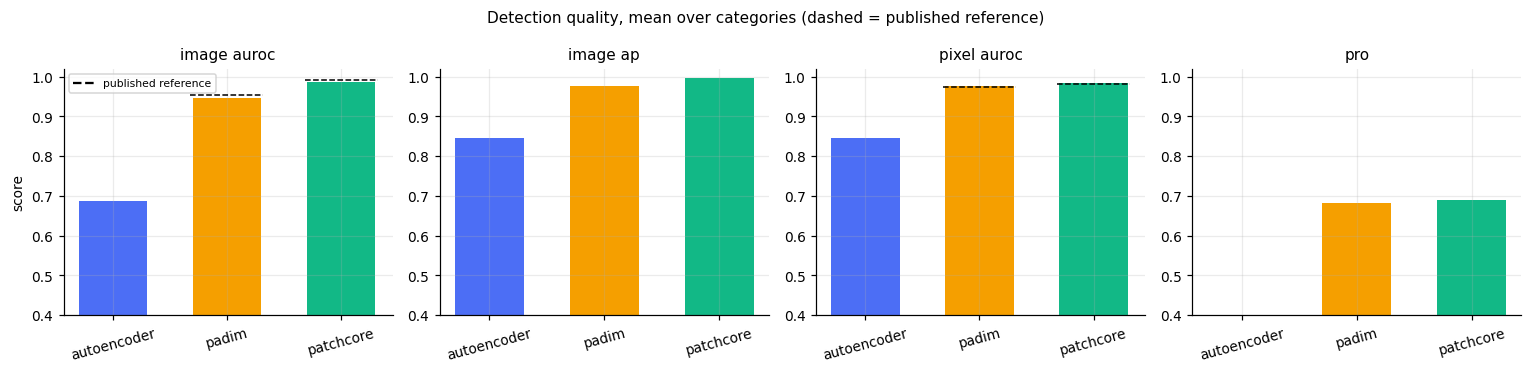

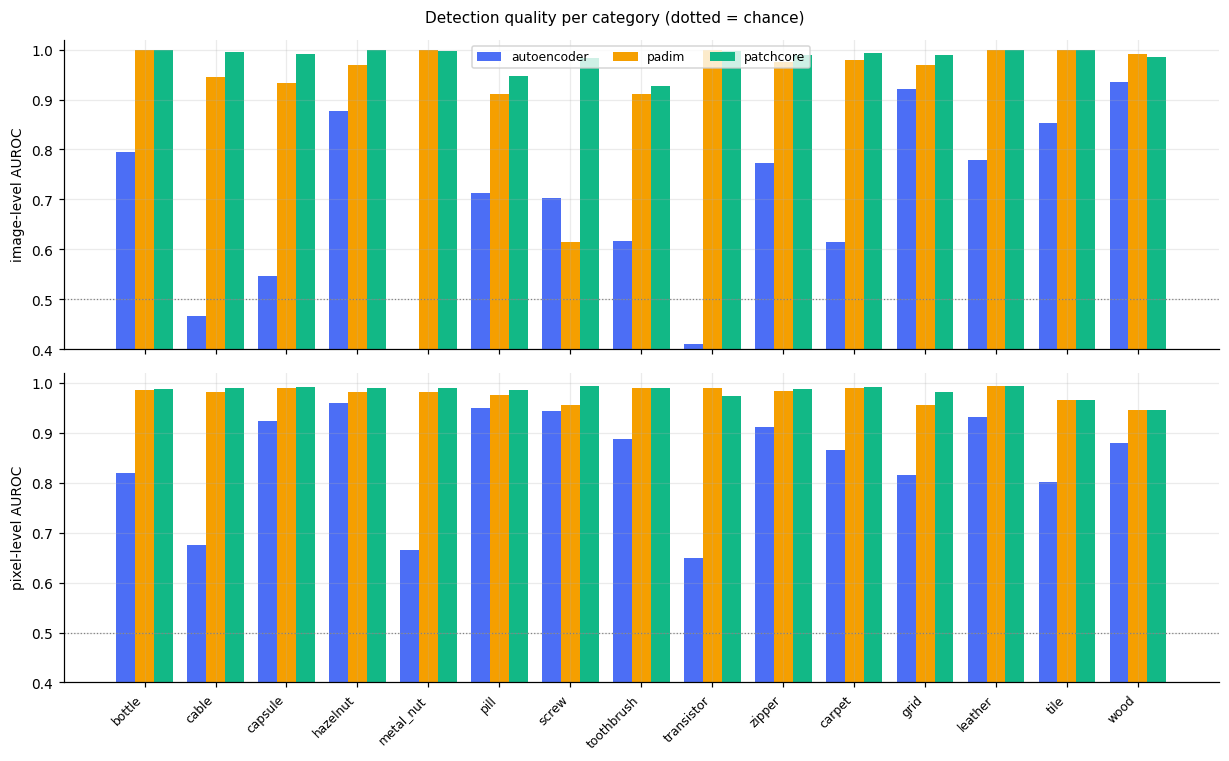

PatchCore image AUROC: best = bottle (1.000), worst = toothbrush (0.928), mean = 0.986


In [ ]:
# @title Evaluation 1 — detection quality on MVTec AD
det_cols = ["category", "detector", "image_auroc", "image_ap", "pixel_auroc", "pro"]
detection_table = METRICS_DF[det_cols].copy()

print("Image-level AUROC by category")
display(detection_table.pivot(index="category", columns="detector", values="image_auroc").round(3))
print("Pixel-level AUROC by category")
display(detection_table.pivot(index="category", columns="detector", values="pixel_auroc").round(3))

summary = detection_table.groupby("detector")[["image_auroc", "image_ap", "pixel_auroc", "pro"]].mean().round(3)
print("Mean over categories")
display(summary)

# Published reference numbers (full MVTec, the authors' own configurations).
# Ours differ in resolution and preprocessing, so a gap is expected; the point
# of the comparison is to catch implementation bugs, not to claim parity.
REFERENCE = {"patchcore": {"image_auroc": 0.991, "pixel_auroc": 0.981},
             "padim": {"image_auroc": 0.955, "pixel_auroc": 0.975}
            }

# --- aggregate: how close are we to the published numbers? -------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, metric in zip(axes, ["image_auroc", "image_ap", "pixel_auroc", "pro"]):
    piv = detection_table.groupby("detector")[metric].mean()
    ax.bar(piv.index, piv.values, color=PALETTE[:len(piv)], width=0.6)
    for i, d in enumerate(piv.index):
        ref = REFERENCE.get(d, {}).get(metric)
        if ref:
            ax.hlines(ref, i - 0.32, i + 0.32, colors="k", linestyles="--", linewidth=1)
    ax.set_ylim(0.4, 1.02)
    ax.set_title(metric.replace("_", " "), fontsize=10)
    ax.tick_params(axis="x", rotation=15)
axes[0].set_ylabel("score")
axes[0].plot([], [], "k--", label="published reference"); axes[0].legend(fontsize=7)
fig.suptitle("Detection quality, mean over categories (dashed = published reference)", fontsize=10)
fig.tight_layout()
fig.savefig(Path(CONFIG.results_dir) / "figures" / "detection_metrics.png", bbox_inches="tight")
plt.show()

# --- per-category spread: this is where the methods separate -----------------
piv = detection_table.pivot(index="category", columns="detector", values="image_auroc")
piv = piv.reindex([c for c in CONFIG.categories if c in piv.index])
fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.75 * len(piv)), 7), sharex=True)
for ax, metric, title in zip(axes, ["image_auroc", "pixel_auroc"],
                             ["image-level AUROC", "pixel-level AUROC"]):
    p = detection_table.pivot(index="category", columns="detector", values=metric)
    p = p.reindex([c for c in CONFIG.categories if c in p.index])
    x = np.arange(len(p))
    width = 0.8 / max(len(p.columns), 1)
    for j, d in enumerate(p.columns):
        ax.bar(x + (j - (len(p.columns) - 1) / 2) * width, p[d].values, width=width,
               label=d, color=PALETTE[j % len(PALETTE)])
    ax.set_ylim(0.4, 1.02)
    ax.set_ylabel(title)
    ax.axhline(0.5, color="grey", lw=0.8, ls=":")
axes[0].legend(fontsize=8, ncol=3)
axes[-1].set_xticks(np.arange(len(piv)))
axes[-1].set_xticklabels(piv.index, rotation=45, ha="right", fontsize=8)
fig.suptitle("Detection quality per category (dotted = chance)", fontsize=10)
fig.tight_layout()
fig.savefig(Path(CONFIG.results_dir) / "figures" / "detection_per_category.png", bbox_inches="tight")
plt.show()

# --- the honest reading ------------------------------------------------------
best = detection_table[detection_table["detector"] == "patchcore"].set_index("category")["image_auroc"]
if len(best):
    print(f"PatchCore image AUROC: best = {best.idxmax()} ({best.max():.3f}), "
          f"worst = {best.idxmin()} ({best.min():.3f}), mean = {best.mean():.3f}")

## 11. Evaluation — severity ranking

The central experiment. Both rankings come from the same detector on the same images; the only difference is what they sort by. The ablation then isolates each factor, with **"intensity only"** standing in for the conventional anomaly score expressed inside the same framework — the gap between that row and "full severity" is the measurable contribution of this work.

**Two targets, reported separately.** `true_magnitude` is pure area × intensity. A raw anomaly score already tracks size and contrast, so severity and the raw score correlate with it about equally — that comparison mostly shows the pipeline is not broken, not that the extra factors help. `impact_magnitude` adds a location term (how much of the defect sits on the object boundary), computed from the object mask alone. That is the target the structural / compactness / contrast factors are designed for, and where severity is expected to pull ahead of a location-blind raw score. `impact_magnitude`'s exact definition is a modelling choice left to you in the synthetic-generator cell; fix it before running the evaluation.

With 15 categories there are enough paired observations to say something about whether the difference is real rather than a lucky category, so a paired test over categories is reported alongside the means. It is not a strong test — the categories are not independent draws from a population and a single seed gives no within-category variance — but it is better than eyeballing two bars.

Mean over categories, by detector


,sev_spearman,raw_spearman,d_spearman,sev_ndcg@10%,raw_ndcg@10%,sev_rank_mae,raw_rank_mae
detector,,,,,,,
autoencoder,0.549,0.461,0.088,0.823,0.739,0.207,0.232
padim,0.618,0.751,-0.134,0.815,0.879,0.190,0.155
patchcore,0.511,0.700,-0.190,0.753,0.831,0.220,0.170



Paired comparison across categories (severity vs raw anomaly score)


,detector,n_categories,severity wins,mean delta,wilcoxon p
0,patchcore,15,2/15,-0.1896,0.0006
1,padim,15,4/15,-0.1336,0.0054
2,autoencoder,15,12/15,0.0876,0.0009


Caveat: categories are not independent samples and there is one seed per cell, so read p as a rough guide, not as inference about a population.


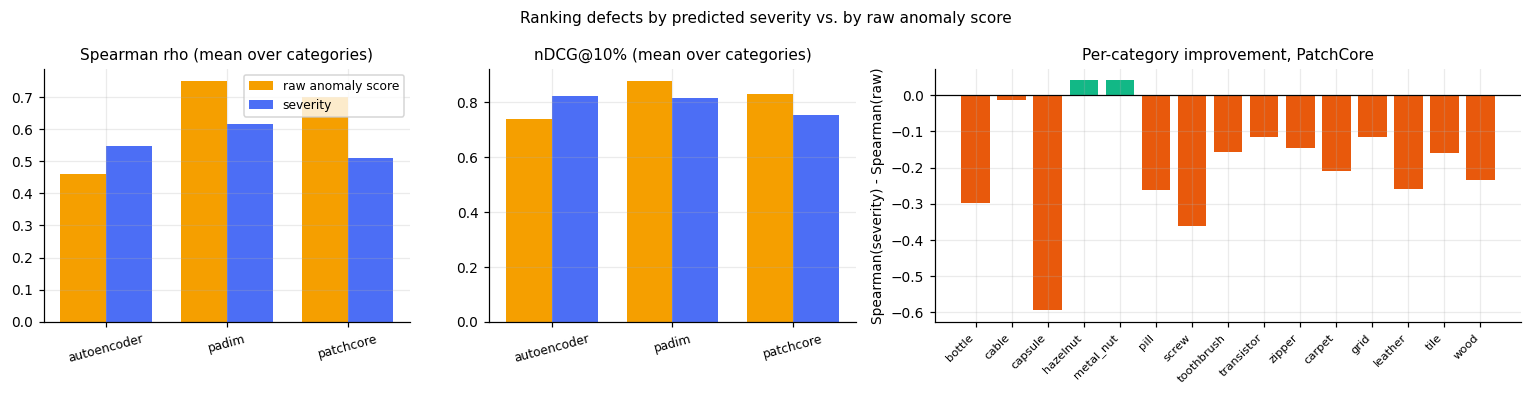


Severity vs raw score, by target (Spearman rho, mean over categories)


,sev_spearman,raw_spearman,d_true,sevimp_spearman,rawimp_spearman,d_impact
detector,,,,,,
autoencoder,0.549,0.461,0.088,0.549,0.463,0.085
padim,0.618,0.751,-0.134,0.622,0.743,-0.121
patchcore,0.511,0.700,-0.190,0.521,0.692,-0.171


d_true   : severity - raw  against area x intensity  (expect ~0: raw already tracks these)
d_impact : severity - raw  against the location-aware target (expect > 0 if the factors earn their keep)

Factor ablation vs true_magnitude, mean over all (category, detector) cells


,spearman,ndcg@10%
variant,,
intensity only (= conventional),0.682,0.861
raw anomaly score,0.635,0.821
- structural,0.599,0.836
- compactness,0.583,0.789
- contrast,0.564,0.775
full severity,0.562,0.799
- extent,0.437,0.752
- intensity,0.423,0.707



Factor ablation vs impact_magnitude, mean over all (category, detector) cells


,spearman,ndcg@10%
variant,,
intensity only (= conventional),0.675,0.841
raw anomaly score,0.631,0.804
- structural,0.592,0.828
- compactness,0.591,0.794
full severity,0.566,0.799
- contrast,0.558,0.767
- extent,0.454,0.760
- intensity,0.434,0.714


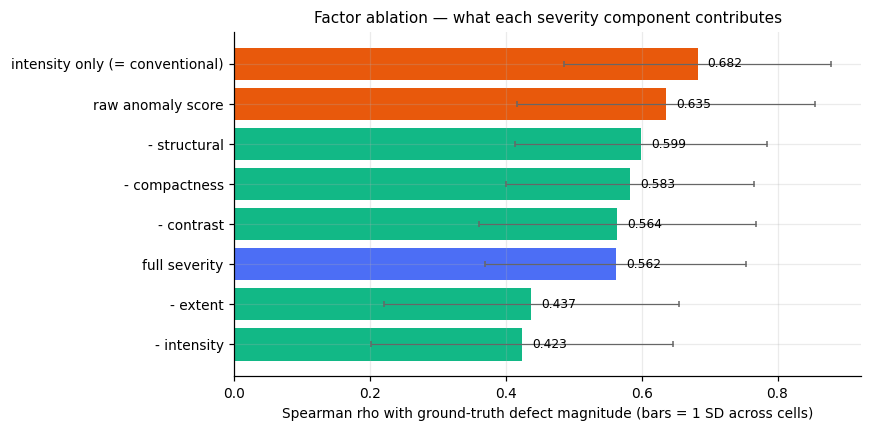


Fusion strategy (held-out half of the synthetic set, Spearman rho)


,manual,ridge,gbm
detector,,,
autoencoder,0.560,0.560,0.551
padim,0.649,0.715,0.681
patchcore,0.565,0.642,0.675


Ridge beats the hand-set weights by +0.048 on average. The hand-set weights stay the default because they are auditable; this number is the price of that choice.


In [ ]:
# @title Evaluation 2 — does severity rank defects better than a raw anomaly score?
#
# This is the experiment the whole proposal stands on. Both columns come from
# the same detector and the same images; the only difference is what we rank by.
from scipy.stats import wilcoxon

comparison = METRICS_DF[["category", "detector",
                         "sev_spearman", "raw_spearman",
                         "sev_kendall", "raw_kendall",
                         "sev_ndcg@10%", "raw_ndcg@10%",
                         "sev_rank_mae", "raw_rank_mae"]].copy()
comparison["d_spearman"] = comparison["sev_spearman"] - comparison["raw_spearman"]

print("Mean over categories, by detector")
display(comparison.groupby("detector")[
    ["sev_spearman", "raw_spearman", "d_spearman",
     "sev_ndcg@10%", "raw_ndcg@10%", "sev_rank_mae", "raw_rank_mae"]].mean().round(3))

# --- is the difference bigger than category-to-category noise? ---------------
print("\nPaired comparison across categories (severity vs raw anomaly score)")
sig_rows = []
for d in comparison["detector"].unique():
    sub = comparison[comparison["detector"] == d].dropna(subset=["sev_spearman", "raw_spearman"])
    if len(sub) < 6:
        continue
    wins = int((sub["d_spearman"] > 0).sum())
    try:
        stat, p = wilcoxon(sub["sev_spearman"], sub["raw_spearman"])
    except Exception:
        stat, p = float("nan"), float("nan")
    sig_rows.append({"detector": d, "n_categories": len(sub),
                     "severity wins": f"{wins}/{len(sub)}",
                     "mean delta": sub["d_spearman"].mean(),
                     "wilcoxon p": p})
if sig_rows:
    display(pd.DataFrame(sig_rows).round(4))
    print("Caveat: categories are not independent samples and there is one seed per cell, "
          "so read p as a rough guide, not as inference about a population.")

# --- aggregate + per-category delta ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6),
                         gridspec_kw={"width_ratios": [1, 1, 1.6]})

for ax, (a, b, title) in zip(axes[:2], [
        ("raw_spearman", "sev_spearman", "Spearman rho"),
        ("raw_ndcg@10%", "sev_ndcg@10%", "nDCG@10%")]):
    g = comparison.groupby("detector")[[a, b]].mean()
    x = np.arange(len(g))
    ax.bar(x - 0.19, g[a], width=0.38, label="raw anomaly score", color=PALETTE[1])
    ax.bar(x + 0.19, g[b], width=0.38, label="severity", color=PALETTE[0])
    ax.set_xticks(x); ax.set_xticklabels(g.index, fontsize=8, rotation=15)
    ax.set_title(title + " (mean over categories)", fontsize=10)
axes[0].legend(fontsize=8)

pc = comparison[comparison["detector"] == "patchcore"].set_index("category")
pc = pc.reindex([c for c in CONFIG.categories if c in pc.index]).dropna(subset=["d_spearman"])
ax = axes[2]
ax.bar(np.arange(len(pc)), pc["d_spearman"].values,
       color=[PALETTE[2] if v > 0 else PALETTE[3] for v in pc["d_spearman"].values])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(np.arange(len(pc)))
ax.set_xticklabels(pc.index, rotation=45, ha="right", fontsize=7.5)
ax.set_ylabel("Spearman(severity) - Spearman(raw)")
ax.set_title("Per-category improvement, PatchCore", fontsize=10)

fig.suptitle("Ranking defects by predicted severity vs. by raw anomaly score", fontsize=10)
fig.tight_layout()
fig.savefig(Path(CONFIG.results_dir) / "figures" / "severity_vs_raw.png", bbox_inches="tight")
plt.show()


# --------------------------------------------------------------------------- #
# The same question against impact_magnitude — the location-aware target the
# severity factors are actually designed for. Raw score is blind to *where* a
# defect sits, so a positive delta here is the case for the extra factors.
# (impact_magnitude's definition is your call — see the synthetic-generator cell.)
# --------------------------------------------------------------------------- #
if "sevimp_spearman" in METRICS_DF.columns:
    imp = METRICS_DF[["category", "detector", "sevimp_spearman", "rawimp_spearman",
                      "sev_spearman", "raw_spearman"]].copy()
    imp["d_impact"] = imp["sevimp_spearman"] - imp["rawimp_spearman"]
    imp["d_true"] = imp["sev_spearman"] - imp["raw_spearman"]
    print("\nSeverity vs raw score, by target (Spearman rho, mean over categories)")
    display(imp.groupby('detector')[['sev_spearman', 'raw_spearman', 'd_true',
                                     'sevimp_spearman', 'rawimp_spearman', 'd_impact']]
            .mean().round(3))
    print("d_true   : severity - raw  against area x intensity  (expect ~0: raw already tracks these)")
    print("d_impact : severity - raw  against the location-aware target (expect > 0 if the factors earn their keep)")


# --------------------------------------------------------------------------- #
# Leave-one-out ablation over the severity factors
# --------------------------------------------------------------------------- #
def ablate(result: Dict, target: str = "true_magnitude") -> pd.DataFrame:
    need = [f"f_{k}" for k in FACTORS] + [target]
    df = result["df_synth"]
    if not set(need).issubset(df.columns):
        return pd.DataFrame()
    df = df.dropna(subset=need)
    if len(df) < 6:
        return pd.DataFrame()
    truth = df[target].values
    k10 = max(1, len(df) // 10)
    rows = [{"variant": "full severity",
             "spearman": spearmanr(df["severity"], truth).correlation,
             "ndcg@10%": ndcg_at_k(df["severity"].values, truth, k10)}]

    factor_rows = df[[f"f_{k}" for k in FACTORS]].to_numpy()
    for drop in FACTORS:
        w = {k: v for k, v in CONFIG.severity_weights.items() if k != drop}
        pred = np.array([fuse_with(dict(zip(FACTORS, r)), w) for r in factor_rows])
        rows.append({"variant": f"- {drop}",
                     "spearman": spearmanr(pred, truth).correlation,
                     "ndcg@10%": ndcg_at_k(pred, truth, k10)})

    rows.append({"variant": "intensity only (= conventional)",
                 "spearman": spearmanr(df["f_intensity"], truth).correlation,
                 "ndcg@10%": ndcg_at_k(df["f_intensity"].values, truth, k10)})
    rows.append({"variant": "raw anomaly score",
                 "spearman": spearmanr(df["raw_score"], truth).correlation,
                 "ndcg@10%": ndcg_at_k(df["raw_score"].values, truth, k10)})
    out = pd.DataFrame(rows)
    out.insert(0, "target", target)
    out.insert(0, "detector", result["detector"])
    out.insert(0, "category", result["category"])
    return out


_abl = [ablate(r, t) for r in RESULTS.values()
        for t in ("true_magnitude", "impact_magnitude")]
ABLATION = pd.concat([a for a in _abl if not a.empty], ignore_index=True) if any(
    not a.empty for a in _abl) else pd.DataFrame(columns=["category", "detector", "variant", "spearman"])

if not ABLATION.empty:
    for _tgt in [t for t in ("true_magnitude", "impact_magnitude") if t in set(ABLATION["target"])]:
        print(f"\nFactor ablation vs {_tgt}, mean over all (category, detector) cells")
        display(ABLATION[ABLATION["target"] == _tgt]
                .groupby("variant")[["spearman", "ndcg@10%"]].mean().round(3)
                .sort_values("spearman", ascending=False))

    _abl_plot = ABLATION[ABLATION["target"] == "true_magnitude"] \
        if "true_magnitude" in set(ABLATION["target"]) else ABLATION
    agg = _abl_plot.groupby("variant")["spearman"].mean().sort_values()
    err = _abl_plot.groupby("variant")["spearman"].std().reindex(agg.index)
    fig, ax = plt.subplots(figsize=(8, 4.0))
    colors = [PALETTE[3] if ("only" in v or "raw" in v) else
              (PALETTE[0] if v == "full severity" else PALETTE[2]) for v in agg.index]
    ax.barh(agg.index, agg.values, xerr=err.values, color=colors,
            error_kw=dict(ecolor="0.4", lw=0.8, capsize=2))
    ax.set_xlabel("Spearman rho with ground-truth defect magnitude (bars = 1 SD across cells)")
    ax.set_title("Factor ablation — what each severity component contributes", fontsize=10)
    for i, v in enumerate(agg.values):
        ax.text(v + 0.015, i, f"{v:.3f}", va="center", fontsize=8)
    fig.tight_layout()
    fig.savefig(Path(CONFIG.results_dir) / "figures" / "ablation.png", bbox_inches="tight")
    plt.show()


# --------------------------------------------------------------------------- #
# Hand-set weights vs. a learned fusion (train/test split on the synthetic set)
# --------------------------------------------------------------------------- #
def learned_vs_manual(result: Dict) -> Dict:
    need = [f"f_{k}" for k in FACTORS] + ["true_magnitude"]
    df = result["df_synth"]
    if not set(need).issubset(df.columns):
        return {}
    df = df.dropna(subset=need)
    if len(df) < 12:
        return {}
    rng = np.random.RandomState(CONFIG.seeds[0])
    idx = rng.permutation(len(df))
    cut = len(df) // 2
    tr, te = df.iloc[idx[:cut]], df.iloc[idx[cut:]]

    rows_tr = [{k: r[f"f_{k}"] for k in FACTORS} for _, r in tr.iterrows()]
    X_te = te[[f"f_{k}" for k in FACTORS]].to_numpy()
    out = {"category": result["category"], "detector": result["detector"],
           "manual": spearmanr(te["severity"], te["true_magnitude"]).correlation}
    for kind in ("ridge", "gbm"):
        est = fit_learned_fusion(rows_tr, tr["true_magnitude"].values, model=kind)
        pred = np.clip(est.predict(X_te), 0, 1)
        out[kind] = spearmanr(pred, te["true_magnitude"]).correlation
    return out


FUSION_DF = pd.DataFrame([x for x in (learned_vs_manual(r) for r in RESULTS.values()) if x])
if not FUSION_DF.empty:
    print("\nFusion strategy (held-out half of the synthetic set, Spearman rho)")
    display(FUSION_DF.groupby("detector")[["manual", "ridge", "gbm"]].mean().round(3))
    gap = float((FUSION_DF["ridge"] - FUSION_DF["manual"]).mean())
    print(f"Ridge beats the hand-set weights by {gap:+.3f} on average. "
          "The hand-set weights stay the default because they are auditable; "
          "this number is the price of that choice.")

## 12. Sensitivity and robustness

A severity score that does not rise with defect size, or with contrast, is not measuring severity. Each sweep pins one parameter and varies the other. The robustness check confirms severity does not swing under nuisance transformations (small rotations, brightness, noise).

Both run on the single experiment kept in memory (`CONFIG.qualitative_category` with PatchCore), because they need a live detector to score newly generated images.

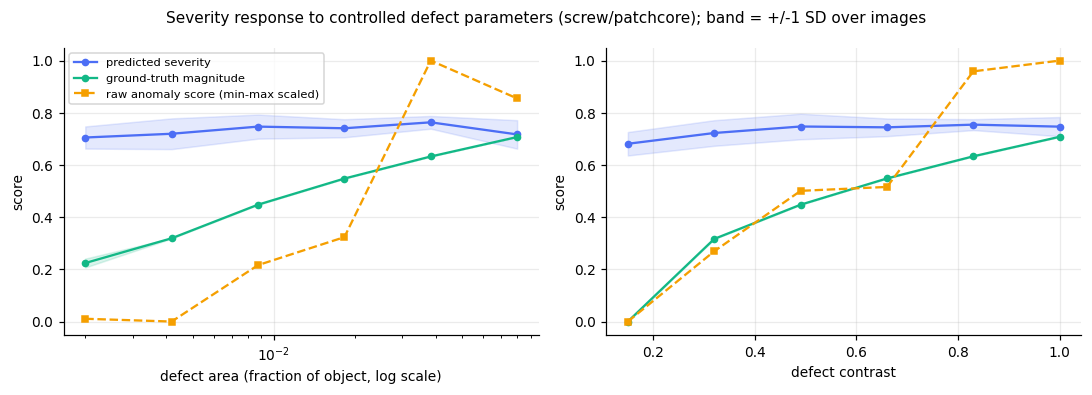

Severity under nuisance perturbations — SD across variants, per image:
  mean SD = 0.021   (severity is on a 0-1 scale)


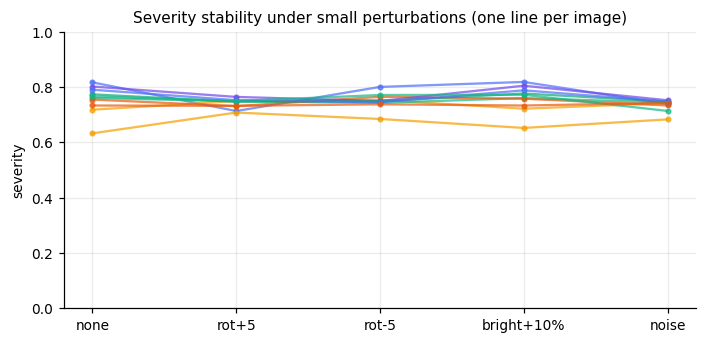

In [ ]:
# @title Evaluation 3 — sensitivity curves and robustness
#
# A severity score that does not increase with defect size, or with defect
# contrast, is not measuring severity. These two sweeps are the sanity check:
# one factor is varied while the other is pinned.

def sensitivity_sweep(result: Dict, vary: str = "area", n_levels: int = 6,
                      n_images: int = 8, cfg: Config = CONFIG) -> pd.DataFrame:
    det, scorer, test_ds = result["detector_obj"], result["scorer"], result["test_ds"]
    img_tf, _ = build_transforms(cfg)
    normals = [s for s in test_ds.samples if s["label"] == 0][:n_images]
    if not normals:
        return pd.DataFrame()

    a_lo, a_hi = cfg.synth_area_range
    i_lo, i_hi = cfg.synth_intensity_range
    if vary == "area":
        levels = np.exp(np.linspace(math.log(a_lo), math.log(a_hi), n_levels))
        fixed = 0.5 * (i_lo + i_hi)
    else:
        levels = np.linspace(i_lo, i_hi, n_levels)
        fixed = math.exp(0.5 * (math.log(a_lo) + math.log(a_hi)))

    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    rows = []
    for li, lvl in enumerate(levels):
        area, inten = (lvl, fixed) if vary == "area" else (fixed, lvl)
        for k, s in enumerate(normals):
            base = denormalize(img_tf(Image.open(s["path"]).convert("RGB")))
            rng = np.random.RandomState(7000 + 97 * li + k)
            corrupted, mask, params = inject_defect(base, "blob", area, inten, rng,
                                                    object_mask=object_mask_for(str(s["path"]), base))
            tens = (torch.from_numpy(corrupted).permute(2, 0, 1).float() - mean_t) / std_t
            raw, amap = det.score(tens)
            report = scorer.assess(corrupted, amap, path=str(s["path"]))
            rows.append({"level": lvl, "severity": report.overall, "raw_score": raw,
                         "true_magnitude": true_magnitude(params["area_frac"], params["intensity"]),
                         "image": k})
    return pd.DataFrame(rows)


def plot_sensitivity(result: Dict):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    for ax, vary, xlabel in zip(axes, ["area", "intensity"],
                                ["defect area (fraction of object, log scale)", "defect contrast"]):
        df = sensitivity_sweep(result, vary=vary)
        if df.empty:
            continue
        g = df.groupby("level")
        for col, colour, label in [("severity", PALETTE[0], "predicted severity"),
                                   ("true_magnitude", PALETTE[2], "ground-truth magnitude")]:
            m, sd = g[col].mean(), g[col].std()
            ax.plot(m.index, m.values, "-o", color=colour, ms=4, label=label)
            ax.fill_between(m.index, m - sd, m + sd, color=colour, alpha=0.15)
        raw = g["raw_score"].mean()
        raw_n = (raw - raw.min()) / (raw.max() - raw.min() + 1e-8)
        ax.plot(raw.index, raw_n.values, "--s", color=PALETTE[1], ms=3.5,
                label="raw anomaly score (min-max scaled)")
        if vary == "area":
            ax.set_xscale("log")
        ax.set_xlabel(xlabel); ax.set_ylabel("score")
        ax.set_ylim(-0.05, 1.05)
    axes[0].legend(fontsize=7.5)
    fig.suptitle(f"Severity response to controlled defect parameters "
                 f"({result['category']}/{result['detector']}); band = +/-1 SD over images", fontsize=10)
    fig.tight_layout()
    fig.savefig(Path(CONFIG.results_dir) / "figures" / "sensitivity.png", bbox_inches="tight")
    plt.show()


_res_keep = RESULTS.get(KEY)
_has_live_detector = _res_keep is not None and _res_keep.get("detector_obj") is not None
if _has_live_detector:
    plot_sensitivity(_res_keep)
else:
    print(f"[skip] no live detector for {KEY} — the qualitative experiment failed or was released.")


# --------------------------------------------------------------------------- #
# Robustness: severity should not swing under nuisance transformations
# --------------------------------------------------------------------------- #
def robustness_check(result: Dict, n_images: int = 10) -> pd.DataFrame:
    det, scorer, synth_ds = result["detector_obj"], result["scorer"], result["synth_ds"]
    rows = []
    for i in range(min(n_images, len(synth_ds))):
        item = synth_ds[i]
        variants = {"none": item["image"]}
        variants["rot+5"] = transforms.functional.rotate(item["image"], 5)
        variants["rot-5"] = transforms.functional.rotate(item["image"], -5)
        variants["bright+10%"] = item["image"] * 1.1
        variants["noise"] = item["image"] + 0.05 * torch.randn_like(item["image"])
        for name, tens in variants.items():
            raw, amap = det.score(tens)
            rep = scorer.assess(denormalize(tens), amap)
            rows.append({"image": i, "perturbation": name, "severity": rep.overall, "raw": raw})
    df = pd.DataFrame(rows)
    piv = df.pivot(index="image", columns="perturbation", values="severity")
    print("Severity under nuisance perturbations — SD across variants, per image:")
    print(f"  mean SD = {piv.std(axis=1).mean():.3f}   (severity is on a 0-1 scale)")
    return df


if _has_live_detector:
    ROBUST_DF = robustness_check(_res_keep)
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    for i, (img, grp) in enumerate(ROBUST_DF.groupby("image")):
        ax.plot(grp["perturbation"], grp["severity"], "-o", ms=3, alpha=0.7,
                color=PALETTE[i % len(PALETTE)])
    ax.set_ylabel("severity"); ax.set_ylim(0, 1)
    ax.set_title("Severity stability under small perturbations (one line per image)", fontsize=10)
    fig.tight_layout()
    fig.savefig(Path(CONFIG.results_dir) / "figures" / "robustness.png", bbox_inches="tight")
    plt.show()
else:
    ROBUST_DF = pd.DataFrame()

## 13. Qualitative results — the ranked inspection queue

The practical deliverable: every test image ordered by severity, worst first, with a full explanation panel for the top of the queue.

The discovery curve underneath is the operational version of the claim. It asks: if an inspector works down the queue and stops after inspecting *x*% of the parts, what fraction of the real defects have they found? A ranking that is better for triage sits higher and further left.

Inspection queue — screw / patchcore (worst first)


,severity,severity_class,defect,label,raw_score,n_regions,f_intensity,f_extent,f_structural,f_compactness,f_contrast
1,0.780,Critical,manipulated_front,1,1.995,3,0.738,0.987,0.632,0.758,0.729
2,0.771,Critical,manipulated_front,1,1.912,2,0.720,0.983,0.650,0.660,0.753
3,0.768,Critical,manipulated_front,1,1.914,1,0.724,1.000,0.584,0.776,0.712
4,0.766,Critical,manipulated_front,1,1.916,3,0.714,1.000,0.574,0.829,0.696
5,0.765,Critical,manipulated_front,1,1.951,2,0.739,1.000,0.608,0.594,0.750
6,0.764,Critical,thread_top,1,2.381,2,0.845,1.000,0.469,0.740,0.615
7,0.759,Critical,manipulated_front,1,1.991,1,0.748,0.847,0.654,0.860,0.707
8,0.756,Critical,scratch_neck,1,2.688,1,0.870,1.000,0.397,0.738,0.617
9,0.751,Critical,thread_top,1,1.976,1,0.744,1.000,0.587,0.528,0.719
10,0.750,Major,manipulated_front,1,1.902,2,0.688,0.887,0.675,0.733,0.755


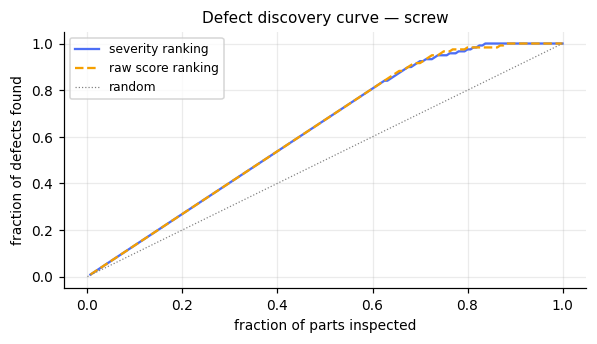


=== queue position 1: 015.png (manipulated_front, severity 0.78) ===


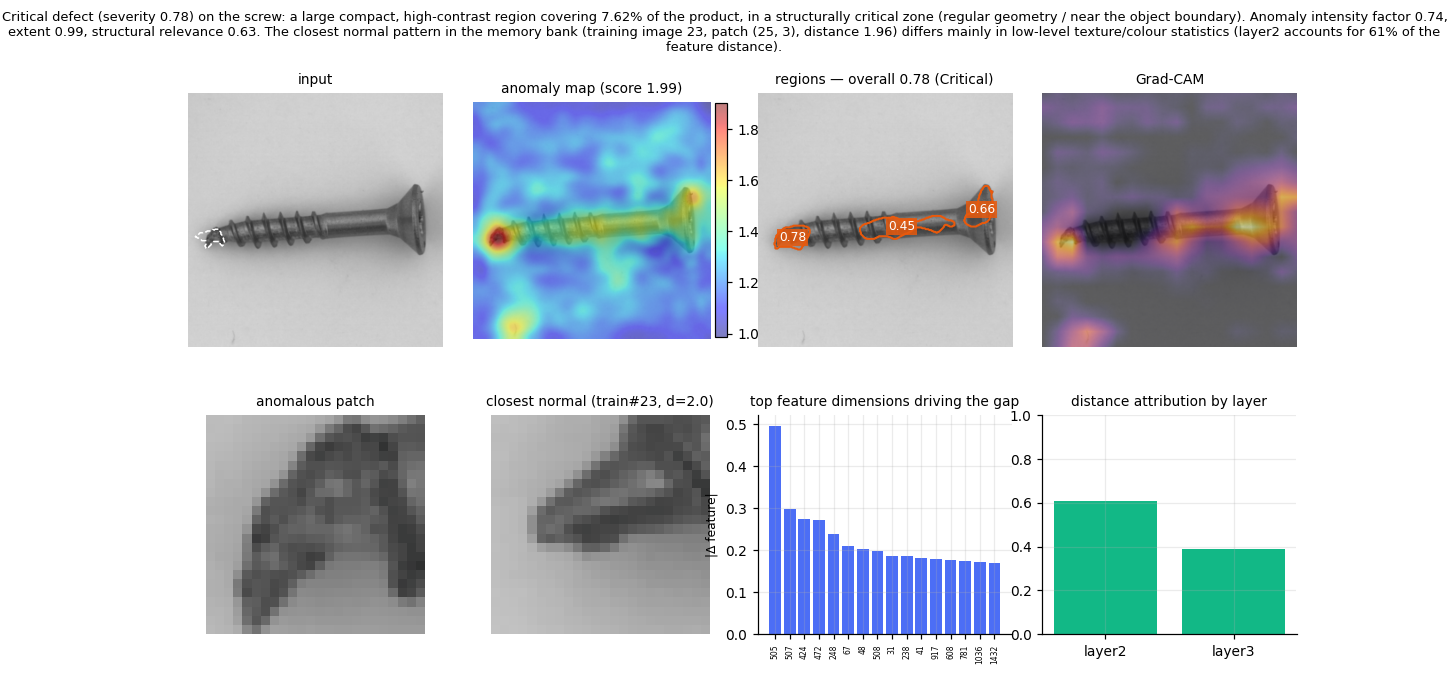


=== queue position 2: 007.png (manipulated_front, severity 0.77) ===


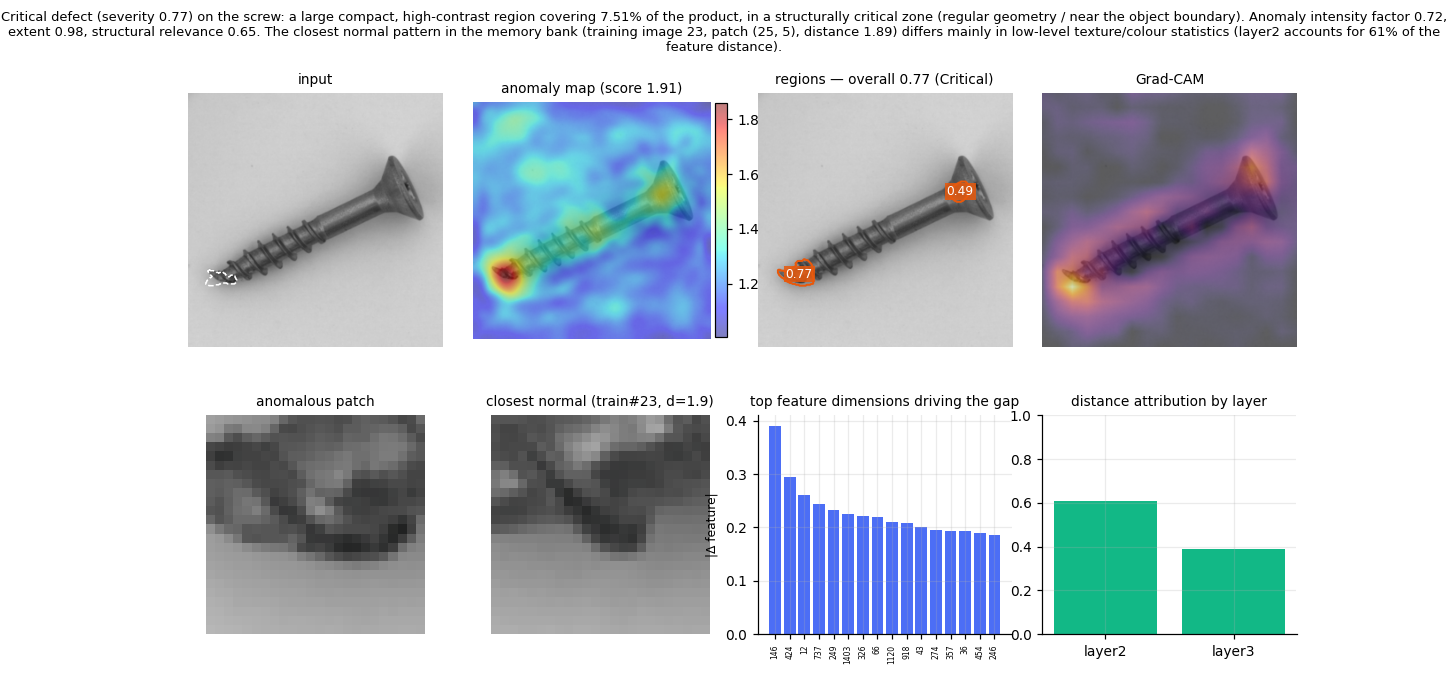


=== queue position 3: 001.png (manipulated_front, severity 0.77) ===


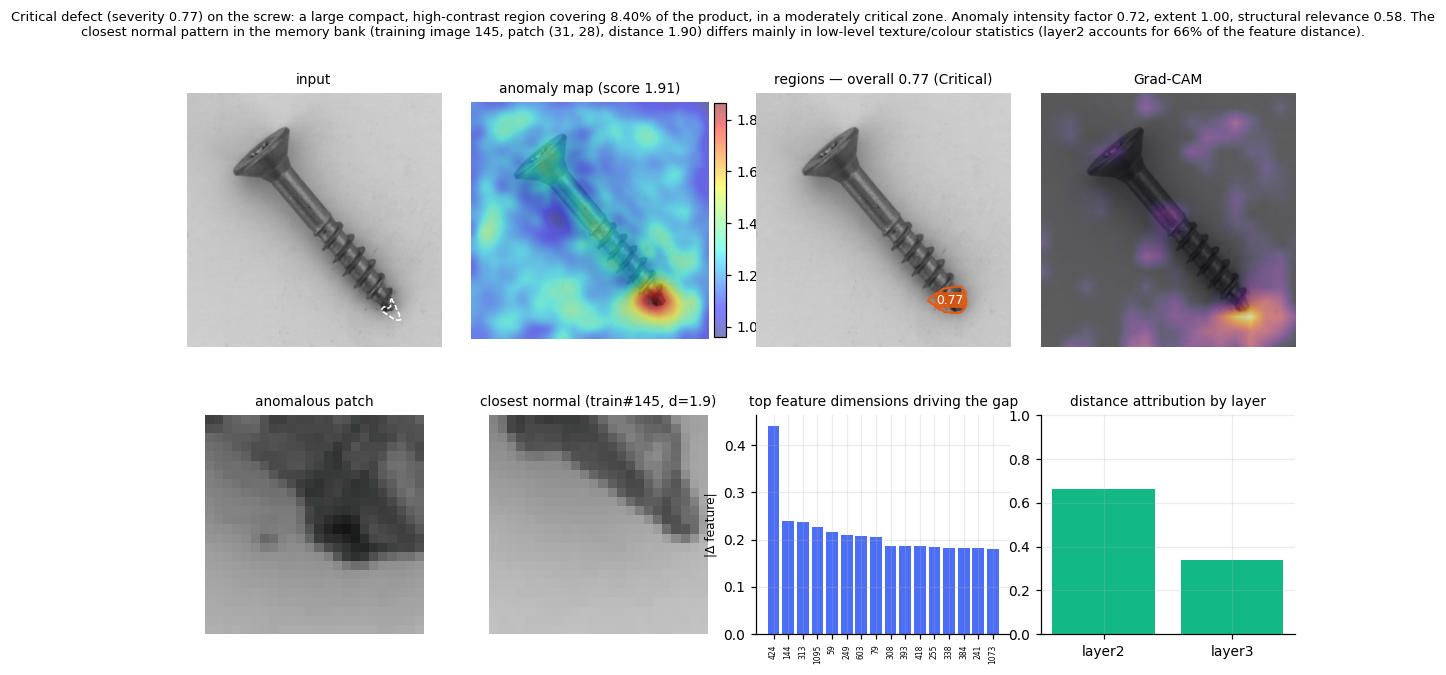

In [ ]:
# @title Qualitative results — the ranked inspection queue
#
# The practical deliverable: every test image ordered by severity, worst first,
# with a full explanation panel for the top of the queue.

def ranked_queue(result: Dict, top_n: int = 20) -> pd.DataFrame:
    df = result["df_mvtec"].sort_values("severity", ascending=False).head(top_n).copy()
    cols = ["severity", "severity_class", "defect", "label", "raw_score", "n_regions",
            *[c for c in df.columns if c.startswith("f_")]]
    df = df[cols]
    df.index = range(1, len(df) + 1)
    return df.round(3)


def discovery_curve(result: Dict, ax=None):
    """Fraction of real defects found vs fraction of parts inspected."""
    ax = ax or plt.subplots(figsize=(5.5, 3.2))[1]
    for col, colour, style, label in [("severity", PALETTE[0], "-", "severity ranking"),
                                      ("raw_score", PALETTE[1], "--", "raw score ranking")]:
        d = result["df_mvtec"].sort_values(col, ascending=False)
        hits = np.cumsum(d["label"].values) / max(d["label"].sum(), 1)
        ax.plot(np.arange(1, len(hits) + 1) / len(hits), hits,
                color=colour, ls=style, label=label)
    ax.plot([0, 1], [0, 1], color="grey", lw=0.8, ls=":", label="random")
    ax.set_xlabel("fraction of parts inspected")
    ax.set_ylabel("fraction of defects found")
    ax.legend(fontsize=8)
    return ax


if _res_keep is not None:
    print(f"Inspection queue — {_res_keep['category']} / {_res_keep['detector']} (worst first)")
    display(ranked_queue(_res_keep))

    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    discovery_curve(_res_keep, ax)
    ax.set_title(f"Defect discovery curve — {_res_keep['category']}", fontsize=10)
    fig.tight_layout()
    fig.savefig(Path(CONFIG.results_dir) / "figures" / "discovery_curve.png", bbox_inches="tight")
    plt.show()


def show_worst(result: Dict, n: int = 3):
    """Full explanation panels for the n highest-severity test images."""
    if result.get("detector_obj") is None:
        print("[skip] detector released; cannot render explanation panels.")
        return
    df = result["df_mvtec"].sort_values("severity", ascending=False)
    test_ds = result["test_ds"]
    figdir = Path(CONFIG.results_dir) / "figures"
    for rank, (_, row) in enumerate(df.head(n).iterrows(), start=1):
        i = int(row["index"])
        item = test_ds[i]
        print(f"\n=== queue position {rank}: {Path(row['path']).name} "
              f"({row['defect']}, severity {row['severity']:.2f}) ===")
        explain_image(result["detector_obj"], result["scorer"], item["image"],
                      category=result["category"], gt_mask=item["mask"][0].numpy(),
                      save_path=figdir / f"explanation_{result['category']}_{rank}.png")


if _has_live_detector:
    show_worst(_res_keep, n=3)

## 14. Interactive demo

No image given — using a random defective test image: 004.png


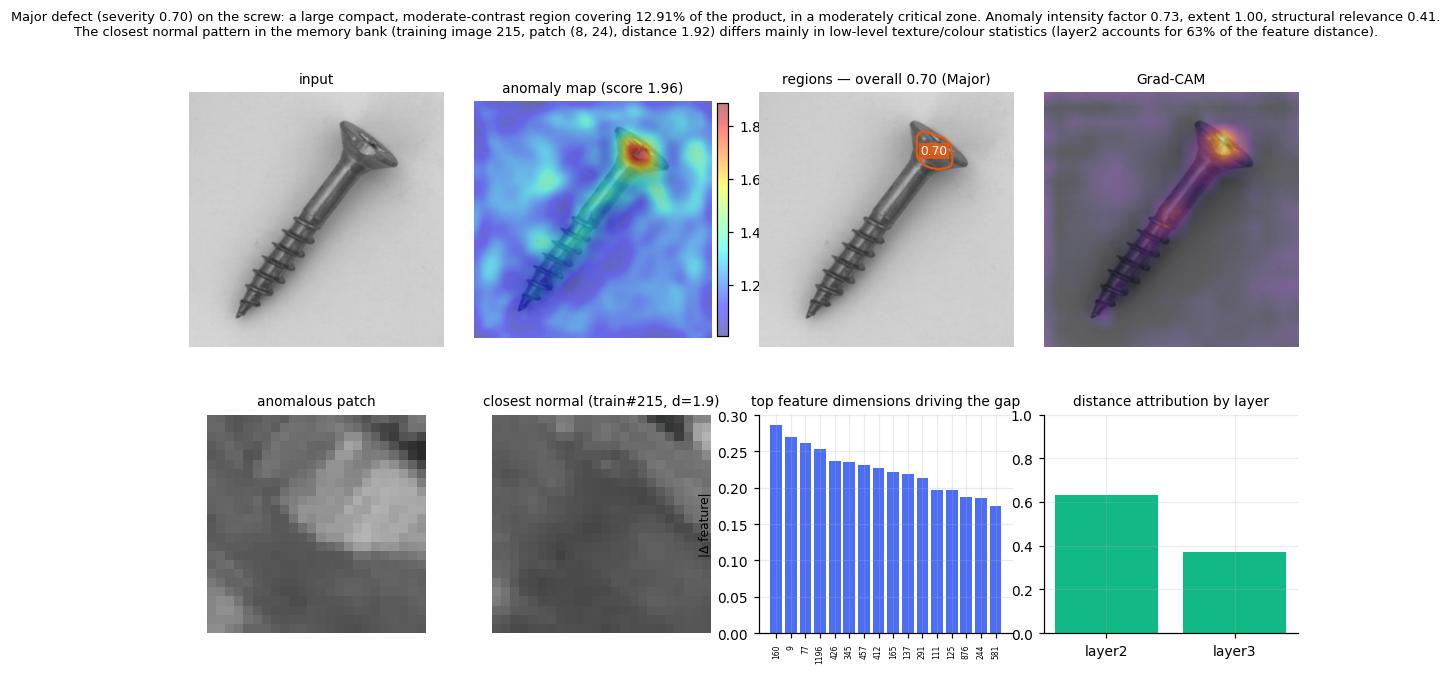


Overall severity: 0.695  ->  Major
Area-weighted severity: 0.695   |   regions found: 1


,region,area_px,area_frac,severity,class,intensity,extent,structural,compactness,contrast
0,1,1372,0.129,0.695,Major,0.725,1.0,0.415,0.883,0.374



Major defect (severity 0.70) on the screw: a large compact, moderate-contrast region covering 12.91% of the product, in a moderately critical zone. Anomaly intensity factor 0.73, extent 1.00, structural relevance 0.41. The closest normal pattern in the memory bank (training image 215, patch (8, 24), distance 1.92) differs mainly in low-level texture/colour statistics (layer2 accounts for 63% of the feature distance).


In [ ]:
# @title Interactive demo — score any image end to end
#
# Run this cell and upload a product image, or leave it to fall back to a random
# defective test image. Note the detector is fitted on ONE category: an image of
# a different product is out of distribution and will (correctly) look anomalous
# everywhere.

DEMO_ASK_FOR_UPLOAD = False   # True -> Colab shows a file picker (blocks 'Run all')


def inspect(image_path: Optional[str] = None, result: Optional[Dict] = None, cfg: Config = CONFIG):
    result = result or _res_keep
    if result is None or result.get("detector_obj") is None:
        print("[skip] no live detector available for the demo.")
        return None
    img_tf, _ = build_transforms(cfg)

    if image_path is None:
        df = result["df_mvtec"]
        cand = df[df["label"] == 1]
        row = (cand if len(cand) else df).sample(1, random_state=int(time.time()) % 1000).iloc[0]
        image_path = row["path"]
        print(f"No image given — using a random defective test image: {Path(image_path).name}")

    tens = img_tf(Image.open(image_path).convert("RGB"))
    out = explain_image(result["detector_obj"], result["scorer"], tens,
                        category=result["category"])
    report = out["report"]

    print(f"\nOverall severity: {report.overall:.3f}  ->  {report.severity_class}")
    print(f"Area-weighted severity: {report.weighted:.3f}   |   regions found: {len(report.regions)}")
    if report.regions:
        display(report.to_frame().round(3))
    print("\n" + polish_with_llm(out["text"]))
    return out


_uploaded = None
if DEMO_ASK_FOR_UPLOAD:
    try:
        from google.colab import files as colab_files
        print("Upload an image (or press Cancel to use a random test image)...")
        _uploaded = colab_files.upload()
    except Exception:
        pass

if _uploaded:
    for _name in _uploaded:
        inspect(_name)
else:
    inspect()

## 15. Export

In [ ]:
# @title Export — metrics, figures, and a written summary
out_dir = Path(CONFIG.results_dir)
(out_dir / "figures").mkdir(parents=True, exist_ok=True)

METRICS_DF.to_csv(out_dir / "metrics.csv", index=False)
if not ABLATION.empty:
    ABLATION.to_csv(out_dir / "ablation.csv", index=False)
if not FUSION_DF.empty:
    FUSION_DF.to_csv(out_dir / "fusion_comparison.csv", index=False)
for (cat, det_name), res in RESULTS.items():
    res["df_mvtec"].to_csv(out_dir / f"per_image_{cat}_{det_name}.csv", index=False)
    res["df_synth"].to_csv(out_dir / f"per_image_synth_{cat}_{det_name}.csv", index=False)

with open(out_dir / "config.json", "w") as fh:
    json.dump({k: (list(v) if isinstance(v, tuple) else v) for k, v in asdict(CONFIG).items()},
              fh, indent=2)


def build_summary() -> str:
    det_mean = METRICS_DF.groupby("detector")[
        ["image_auroc", "image_ap", "pixel_auroc", "pro"]].mean().round(3)
    sev_mean = METRICS_DF.groupby("detector")[
        ["sev_spearman", "raw_spearman", "sev_ndcg@10%", "raw_ndcg@10%"]].mean().round(3)
    per_cat = METRICS_DF.pivot(index="category", columns="detector", values="image_auroc").round(3)
    gain = float((METRICS_DF["sev_spearman"] - METRICS_DF["raw_spearman"]).mean())
    gain_impact = (float((METRICS_DF["sevimp_spearman"] - METRICS_DF["rawimp_spearman"]).mean())
                   if "sevimp_spearman" in METRICS_DF.columns else float("nan"))
    total_min = float(METRICS_DF["runtime_s"].sum()) / 60

    lines = [
        "# Severity-Aware Industrial Anomaly Detection — Results",
        "",
        f"Run on {time.strftime('%Y-%m-%d %H:%M')} | FAST_MODE={CONFIG.fast_mode} | "
        f"backbone={CONFIG.backbone} | input={CONFIG.crop_size}px | "
        f"{len(CONFIG.categories)} categories | seed={CONFIG.seeds[0]} | "
        f"{total_min:.0f} min of fitting/scoring",
        "",
        "## Detection quality (MVTec AD)", "", det_mean.to_markdown(), "",
        "### Image-level AUROC per category", "", per_cat.to_markdown(), "",
        "## Severity ranking (synthetic controlled-defect set)", "", sev_mean.to_markdown(), "",
        f"Mean improvement in Spearman rho, severity vs raw anomaly score:",
        f"- against area x intensity (`true_magnitude`): **{gain:+.3f}**",
        f"- against the location-aware target (`impact_magnitude`): **{gain_impact:+.3f}**",
        "",
    ]
    if not ABLATION.empty:
        abl = ABLATION.groupby("variant")["spearman"].mean().round(3).sort_values(ascending=False)
        lines += ["## Factor ablation", "", abl.to_markdown(), ""]
    lines += [
        "## Reading these numbers",
        "",
        "- Detection metrics say whether a part is defective. They are computed on MVTec, "
        "where ground-truth masks exist.",
        "- Ranking metrics say whether the system puts the *worst* defects first. They are "
        "computed on the synthetic set, because MVTec carries no severity ground truth.",
        "- The ablation isolates each factor's contribution. The 'intensity only' row is the "
        "conventional anomaly score expressed in the same framework; the gap between it and "
        "'full severity' is the contribution of this work.",
        "- One seed per cell. Differences smaller than the category-to-category spread should "
        "not be read as real.",
    ]
    if CONFIG.fast_mode:
        lines += ["", "> FAST_MODE was on: a smaller backbone, one category and fewer images. "
                      "Absolute numbers are below the full-run values and one category cannot "
                      "compare methods. Re-run with fast_mode = False before quoting anything."]
    return "\n".join(lines)


summary_md = build_summary()
(out_dir / "results_summary.md").write_text(summary_md)
print(summary_md)

# Written OUTSIDE results_dir: make_archive walks root_dir while writing, so a
# zip created inside the directory it is archiving can pick up a partial copy
# of itself.
archive_path = out_dir.parent / "anomaly_results.zip"
try:
    shutil.make_archive(str(archive_path.with_suffix("")), "zip", out_dir)
    print(f"\nEverything archived to {archive_path}")
except Exception as exc:
    print(f"[warn] archive failed: {exc}")
print(f"All artefacts written to {out_dir}")

# Severity-Aware Industrial Anomaly Detection — Results

Run on 2026-08-29 10:45 | FAST_MODE=False | backbone=wide_resnet50_2 | input=288px | 15 categories | seed=0 | 80 min of fitting/scoring

## Detection quality (MVTec AD)

| detector    |   image_auroc |   image_ap |   pixel_auroc |   pro |
|:------------|--------------:|-----------:|--------------:|------:|
| autoencoder |         0.688 |      0.845 |         0.845 | 0.388 |
| padim       |         0.946 |      0.977 |         0.977 | 0.683 |
| patchcore   |         0.986 |      0.996 |         0.983 | 0.689 |

### Image-level AUROC per category

| category   |   autoencoder |   padim |   patchcore |
|:-----------|--------------:|--------:|------------:|
| bottle     |         0.794 |   0.998 |       1     |
| cable      |         0.467 |   0.944 |       0.995 |
| capsule    |         0.547 |   0.934 |       0.992 |
| carpet     |         0.615 |   0.978 |       0.994 |
| grid       |         0.921 |   0.97  |       0.988 |
| haze